In [32]:
import os
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Conv2D,Conv3D, BatchNormalization, add, Reshape, UpSampling3D,
                                     ReLU, Add, GlobalAveragePooling2D, Concatenate,
                                     Dense, Input, Layer, Dropout, Activation,
                                     Embedding, LayerNormalization, MultiHeadAttention, Softmax)
from tensorflow.keras.initializers import TruncatedNormal
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.constraints import Constraint
from einops import rearrange
from einops.layers.tensorflow import Rearrange

gpu_server_dir = "/home/jskwon/Desktop/projects/ongoing/NTC_SUB3/assy3d_BOC/"
#current_dir = r'F:\src\github.com\JSK3226\sandbox\ai-surrogate\candidate_vision_models\compare with model_core_p3d_fa_astra_241224\sample_train_data_241224'
#home_dir = r"C:\Users\Jungseok Kwon\Desktop\src\github.com\JSK3226\sandbox\ai-surrogate\candidate_vision_models\compare with model_core_p3d_fa_astra_241224\sample_train_data_241224"
#os.chdir(current_dir)
os.chdir(gpu_server_dir)

#os.getcwd()

#### LOG

Alpha_V1 -> V2
- alpha_v1 버전에서는 하나의 입력만 이용하도록 구성하였으나, 정확도 향상을 위해서 제어봉 입력을 추가로 받도록 기존 모델 변형 필요
- 우선은, alpha_v1에 사용했던 데이터 순서가 제어봉위치 데이터 순서와 호환되는지 확인 필요 -> 호환 안됨
- (변환 완료) 따라서, 기존에 param_list로 저장해뒀던걸 3D 제어봉 형태로 변환해야함, aicorekit 모듈에서 해당 코드 작성하도록 하자



Alpha V2 -> V3
- Stem layer에 batch norm 제거하고 수행

Alpha v3 -> v4 (예정)
- 아마 superposition layer가 유용한지 아닌지를 확인하려고 했었음
- CNN이 없는 어텐션의 경우에서는 Inductive Bias의 역할을 할 수 있었지만 Voxel Attention alpha version의 경우에는 CNN을 함께 사용하므로 성능에 유의미한 영향이 없을 수 있음


데이터

In [31]:
x_train.shape, x_valid.shape, x_test.shape

((32089, 24, 5, 5, 10), (1689, 24, 5, 5, 10), (3754, 24, 5, 5, 10))

In [2]:
from sklearn.model_selection import train_test_split

strategy = tf.distribute.MirroredStrategy()
BATCH_SIZE_PER_REPLICA = 32
GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync


input_xs_voxel_4d = np.load("train_dataset/train_data_250314_processed/boc_mac_xs_matrices4d_09MAY24.npy", allow_pickle=True)
input_rod_voxel_3d = np.load("train_dataset/train_data_250314_processed/rod_position/boc_assywise_rod_position_voxel_3d_normalized_09MAY24.npy", allow_pickle=True)
y_p3d = np.load("train_dataset/train_data_250314_processed/boc_assy_p3d_matrices_09MAY24.npy", allow_pickle=True)

(x_xs_train, x_xs_test,
 x_rod_train, x_rod_test,
 y_train, y_test) = train_test_split(input_xs_voxel_4d,     # 첫 번째 입력
                                     input_rod_voxel_3d,    # 두 번째 입력
                                     y_p3d,                 # 출력
                                     test_size=0.1, random_state=42)
 
(x_xs_train, x_xs_valid,
 x_rod_train, x_rod_valid,
 y_train, y_valid) = train_test_split(x_xs_train,            # 첫 번째 입력 (train)
                                      x_rod_train,           # 두 번째 입력 (train)
                                      y_train,               # 출력 (train)
                                      test_size=0.05, random_state=22)

train_dataset = tf.data.Dataset.from_tensor_slices(((x_xs_train, x_rod_train), y_train))
train_dataset = train_dataset.batch(GLOBAL_BATCH_SIZE, drop_remainder=True)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices(((x_xs_valid, x_rod_valid), y_valid))
valid_dataset = valid_dataset.batch(GLOBAL_BATCH_SIZE)
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(((x_xs_test, x_rod_test), y_test))
test_dataset = test_dataset.batch(GLOBAL_BATCH_SIZE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("Train Dataset Spec:", train_dataset.element_spec)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2')


2025-07-31 10:50:25.318876: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43681 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:2a:00.0, compute capability: 8.6
2025-07-31 10:50:25.320175: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43681 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:3d:00.0, compute capability: 8.6
2025-07-31 10:50:25.321350: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43681 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:ab:00.0, compute capability: 8.6


Train Dataset Spec: ((TensorSpec(shape=(96, 24, 5, 5, 10), dtype=tf.float64, name=None), TensorSpec(shape=(96, 24, 5, 5), dtype=tf.float64, name=None)), TensorSpec(shape=(96, 24, 5, 5), dtype=tf.float64, name=None))


MaxViT 이용할 것
- 각 Stage는 Conv -> Block att -> Grid att를 수행
    - Stage마다 차원변경 & 공간적 다운샘플링이 일어나는데, 이건 MBConv가 수행함. 다른 attn 레이어들은 차원을 건드릴 필요는 없음
- 원래 어텐션은 positional encoding이 필요했으나, Conv를 사용함에 따라 필요 X
- Block att: Local att
- Grid att: Global Sparse att

## 1. 레이어 구성
- MBConv : x <- x + Proj(SE(DWConv(Conv(Norm(X)))))
    - Norm: BatchNorm
    - Activation: GELU
    - DWConv: Depthwise Conv
    - SE: Squeeze-Excitation layer
- Relative Attention(Q,K,V): softmax(QK^T / root(d) + B) * V 
    - B만 빼면, 원래 점곱 어텐션
    - B의 경우는 두 픽셀간의 상대적인 거리에 대한 편향값 (**이걸 3차원으로 구현하는게 어려울 듯)
- Block Attention: (H,W,C) -> ((H/P)xP, (W/P)xP, C) -> ((HW/P^2), P^2, C)
- Grid Attention: (H,W,C) -> ((GxH/G), (GxW/G), C) -> (G^2, HW/G^2, C) ->(HW/G^2, G^2, C)

### 0) Auxiliary Layer (Input tensor manipulation)
- BoundaryPad: 입력 Voxel 텐서에 경계조건 부여
    - inner: 대칭조건 (특정 행,열 전 후 대칭)
    - outer: zero padding
- SuperpositioningNeighborCells: 특정 Cell의 이웃 채널(XS)을 수집하여 중첩시킨 텐서를 생성

In [3]:
class BoundaryPad(Layer):
    """
    물리적 경계 조건에 따라 텐서에 패딩을 적용하는 레이어.

    - Input shape:  (B, D, H, W, C) -> 예: (B, 24, 5, 5, 10)
    - Output shape: (B, D+2, H+2, W+2, C) -> 예: (B, 26, 7, 7, 10)

    적용되는 패딩 규칙:
    - Z축 (D, 위/아래): Zero Padding (양방향)
    - Y축 (H, 안쪽/바깥쪽): 안쪽은 Reflect, 바깥쪽은 Zero Padding
    - X축 (W, 안쪽/바깥쪽): 안쪽은 Reflect, 바깥쪽은 Zero Padding
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # 포맷: [[B_pad], [D_pad], [H_pad], [W_pad], [C_pad]]
        self.z_axis_padding = [[0, 0], [1, 1], [0, 0], [0, 0], [0, 0]]
        
        # 안쪽(시작 부분) 패딩
        self.y_axis_reflect_padding = [[0, 0], [0, 0], [1, 0], [0, 0], [0, 0]]
        self.x_axis_reflect_padding = [[0, 0], [0, 0], [0, 0], [1, 0], [0, 0]]
        
        # 바깥쪽(끝 부분) 패딩
        self.y_axis_zero_padding = [[0, 0], [0, 0], [0, 1], [0, 0], [0, 0]]
        self.x_axis_zero_padding = [[0, 0], [0, 0], [0, 0], [0, 1], [0, 0]]

    def call(self, x):
        # 1. Z축 (위/아래)에 Zero Padding을 적용
        x_padded = tf.pad(x, self.z_axis_padding, mode='CONSTANT', constant_values=0) # (B, 24, 5, 5, C) -> (B, 26, 5, 5, C)

        # 2. Y축 (안쪽/바깥쪽)에 패딩을 순차적으로 적용
        # 안쪽(h=0)에 Reflect Padding 적용
        x_padded = tf.pad(x_padded, self.y_axis_reflect_padding, mode='REFLECT') # (B, 26, 5, 5, C) -> (B, 26, 6, 5, C)
        # 바깥쪽(h=4)에 Zero Padding 적용
        x_padded = tf.pad(x_padded, self.y_axis_zero_padding, mode='CONSTANT', constant_values=0) # (B, 26, 6, 5, C) -> (B, 26, 7, 5, C)

        # 3. X축 (안쪽/바깥쪽)에 패딩을 순차적으로 적용 
        # 안쪽(w=0)에 Reflect Padding 적용
        x_padded = tf.pad(x_padded, self.x_axis_reflect_padding, mode='REFLECT') # (B, 26, 7, 5, C) -> (B, 26, 7, 6, C)
        # 바깥쪽(w=4)에 Zero Padding 적용
        x_padded = tf.pad(x_padded, self.x_axis_zero_padding, mode='CONSTANT', constant_values=0) # (B, 26, 7, 6, C) -> (B, 26, 7, 7, C)
        
        return x_padded

SuperpositioningNeighborCells Layer

In [4]:
class SuperpositioningNeighborCells(Layer):
    """
    Voxel을 구성하는 하나의 Cell은 num_channels 만큼의 채널 개수를 가지며
    각 Cell을 기준으로 (상,하,좌,우,앞,뒤)의 6개의 Cell을 중첩시키는 레이어
    실제로는 각각의 Cell이 아닌 전체 Voxel을 중첩시켜 새로운 Voxel로 만드는 방식
    경계면	    물리적 의미	                                   적용할 패딩
    Z축 (D)     위/아래	노심의 상하단부	                        Zero Padding
    Y축 (H)     안쪽 (h=0)	노심 중심부, 다른 사분 노심과 대칭	 Reflect Padding
    Y축 (H)     바깥쪽 (h=4)	냉각재와 닿는 외부 표면	        Zero Padding
    X축 (W)     안쪽 (w=0)	노심 중심부, 다른 사분 노심과 대칭	 Reflect Padding
    X축 (W)     바깥쪽 (w=4)	냉각재와 닿는 외부 표면	        Zero Padding

    Input_shape = (B,D,H,W,C)
    # B, D, H, W, C = input_shape[0], input_shape[1], input_shape[2], input_shape[3], input_shape[4] # (None, 24, 5, 5, 10)
    Output shape: (B,D,H,W,7,C)
    """
    def __init__(self, **kwargs): # `뭘 입력으로 받는지 보다는?` 여기는 레이어의 특정 인자를 초기화하는 역할이니까?
        super().__init__(**kwargs)
        self.paddings_bidirectional = [[0, 0], [1, 1], [1, 1], [1, 1], [0, 0]] # 대칭조건을 적용할 부분, 차원의 [맨앞, 맨뒤]

    def call(self, x):
        input_shape = tf.shape(x)
        B, D, H, W, C = input_shape[0], input_shape[1], input_shape[2], input_shape[3], input_shape[4]
        x_padded_zero = tf.pad(x, self.paddings_bidirectional, mode = 'CONSTANT', constant_values=0) # 사분 노심의 바깥부분(즉, 냉각재와 닿는 노심의 표면은 0으로 매핑)
        x_padded_reflect =  tf.pad(x, self.paddings_bidirectional, mode = 'REFLECT')

        # 입력된 텐서에서 (D,H,W)를 하나의 Voxel로 보며, 각 Cell의 이웃들의 채널을 하나로 합치기 위함
        x_center = x
        # 노심 위아래는 냉각재가 들어가므로 '0'으로 패딩
        x_axial_down = x_padded_zero[:, :-2, 1:-1, 1:-1, :] # 아래칸이 위로 올라온거임
        x_axial_up = x_padded_zero[:, 2:, 1:-1, 1:-1, :]

        # 안쪽은 'Reflect' 조건으로 패딩, 밖은 '0' 패딩
        x_height_back   = x_padded_reflect[:, 1:-1, :-2, 1:-1, :] # 인덱스의 먼쪽 (Pad, 0, 1, 2, 3, [4, Pad]) 에서 4와 Pad를 제거, 
                                                                # 원본   (  0, 1, 2, 3, 4) 즉 중심 '2'는 원점에 가까운, Cell_back인 '1'과 겹침
                                                                # 바깥쪽에도 reflective 조건으로 패딩되지만, 어차피 [4, Pad]가 함께 제거됨
        x_height_front = x_padded_zero[:, 1:-1, 2:, 1:-1, :] # 인덱스의 안쪽 ([Pad, 0], 1, 2, 3, 4, Pad)에서 Pad와 0을 제거, Pad는 0이 부여됨(노심 외곽)
                                                             # 원본                   (0, 1, 2, 3, 4)에서 중심 '2'는 앞쪽 '3'과 겹침
        x_width_left  = x_padded_reflect[:, 1:-1, 1:-1, :-2, :]
        x_width_right = x_padded_zero[:, 1:-1, 1:-1, 2:, :]

        # 이웃 텐서를 stack, 원래 텐서의 shape: (B,D,H,W,C), 이웃 텐서를 모두 모으면 (B,D,H,W,7,C)
        gathered_neighbors = tf.stack([
                x_center, 
                x_axial_down, x_axial_up, 
                x_height_back, x_height_front, 
                x_width_left, x_width_right
            ],
            axis=-2 
        )
        # gathered_neighbors # shape: (B,D,H,W,7,C)
        
        output = tf.reshape(gathered_neighbors, (B, D, H, W, 7 * C))
        
        return output

### 1) MBConv Layer
- SE: AxialSE layer(원래 이름: Project & Excite)
- MBConv Layer
    - DepthwiseConv3D: 기본 제공 Conv3D의 'group'옵션을 사용하면 DepthwiseConv3D 방식으로 활용가능

#### AxialSE Layer

In [5]:
from tensorflow.keras.initializers import VarianceScaling

class AxialSE(Layer):
    """
    3D형 데이터를 위해 설계된 SE 방식, 전역 풀링 대신, 각 축(D,H,W)을 따라 개별적으로 평균 풀링을 수행
    모든 위치, 모든 채널 각각에 대해 고유한 가중치를 생성하며 (x,y,z) 위치의 k번째 채널은 얼마나 중요한지를 판단하는 방식
    
    과정)
    1) Projection(투영): 각 축에 대해 풀링
        - 너비(W) 축을 따라 정보를 압축 (→ (B,C,1,1,W))
        - 높이(H) 축을 따라 정보를 압축(→(B,C,1,H,1))
        - 깊이(D) 축을 따라 정보를 압축(→ (B, C, D, 1, 1))
        - 세가지 압축된 텐서를 합산하여 각 위치가 자신의 깊이, 행, 열에 대한 정보를 모두 갖도록 컨텍스트 정보를 생성
    2) Exite(활성화): 컨텍스트 텐서를 1x1x1 Conv layer를 사용한 병목구조에 통과시켜 SE 맵을 생성함
    3) Scale(재보정): 최종 SE 맵은 (B,D,H,W,C)의 크기를 가지며, 원래 텐서와 요소별로 곱해짐
    
    Input: (B, D, H, W, C)
    Output: (B, D, H, W, C); Same shape as Input tensor
    """

    def __init__(self, reduction_ratio=2, **kwargs):
        """
        Args:
            reduction_ratio: 병목(bottleneck) 구조에서 채널 수를 얼마나 줄일지에 대한 비율
        """
        super(AxialSE, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
        # 커널 가중치 초기화
        #self.kernel_initializer = tf.random_normal_initializer(stddev=0.02) # 정규분포 이용
        #self.kernel_initializer = tf.truncated_normal_initializer(stddev=0.02) # **절단 정규분포 이용
        self.kernel_initializer = tf.keras.initializers.TruncatedNormal(stddev=0.02)

    def build(self, input_shape):
        """
        레이어의 가중치(variables)를 생성하는 메소드, 레이어가 처음 사용될 때 자동으로 호출

        Args:
            input_shape: 입력 텐서의 형태, 예: (B, D, H, W, C)
        """
        # input_shape[-1]은 채널 수(C)를 의미합니다.
        num_channels = input_shape[-1]
        num_channels_reduced = num_channels // self.reduction_ratio # e.g., (B,26,7,7,10) -> (B,26,7,7,5)

        # 채널 감소(병목)를 위한 Convolution 레이어
        self.conv_channel_reduce = Conv3D(
            filters=num_channels_reduced,
            kernel_size=1,
            strides=1,
            padding='same',
            kernel_initializer=self.kernel_initializer,
            name='AxialSE_conv_reduction'
        )

        # 원래의 채널 수로 복원
        self.conv_channel_expanse = Conv3D(
            filters=num_channels,
            kernel_size=1,
            strides=1,
            padding='same',
            kernel_initializer=self.kernel_initializer,
            name='AxialSE_conv_expansion'
        )

        self.gelu = Activation('gelu')
        self.sigmoid = Activation('sigmoid')
        self.add = Add()

        # super를 메서드 마지막에 작성: 모든 준비가 끝났음을 부모 클래스에 알리고, 최종 마무리 작업을 위임
            # 자식 클래스인 AxialSE가 자신의 모든 가중치와 하위 레이어를 정의하고 설정하는 작업을 먼저 완료 (self.built = True라는 플래그)
        super(AxialSE, self).build(input_shape)

    def call(self, input_tensor):
        """
        레이어의 순전파(forward pass)

        Args:
            input_tensor: X, 형태 = (B, D, H, W, C)
        
        Return:
            어텐션이 적용된 결과 텐서, 형태 = (B, D, H, W, C)
        """
        # --- 1. Axial Squeeze (project) 단계 ---
        # reduce_mean을 사용하여 다른 축들을 따라 평균을 계산 (AveragePooling 레이어의 경우는 해당 연산에 비적합)
        # 브로드캐스팅을 위해 텐서의 랭크(차원 수)를 유지하는 `keepdims=True`를 사용 (즉, 1로 줄어드는 차원을 제거하지 않고 남겨놓는 것)
        # 평균을 계산할 축은 [D, H, W]에 해당하는 [1, 2, 3]

        # 1. Depth(D)와 Height(H) 축을 따라 평균을 계산
        squeeze_tensor_w = tf.reduce_mean(input_tensor, axis=[1, 2], keepdims=True) # 텐서 형태: (B, 1, 1, 7, 10)
        # 2. Depth(D)와 Width(W) 축을 따라 평균을 계산
        squeeze_tensor_h = tf.reduce_mean(input_tensor, axis=[1, 3], keepdims=True) # 텐서 형태: (B, 1, 7, 1, 10)
        # 3. Height(H)와 Width(W) 축을 따라 평균을 계산
        squeeze_tensor_d = tf.reduce_mean(input_tensor, axis=[2, 3], keepdims=True) # 텐서 형태: (B, 26, 1, 1, 10)
    
        # 투영된 텐서들을 결합, 브로드캐스팅으로 인해 원본 공간 크기를 가지는 텐서가 생성
            # 텐서의 각 요소는 자신의 D, H, W 평면(plane)으로부터 온 컨텍스트(문맥) 정보를 포함
        final_squeeze_tensor = self.add([squeeze_tensor_w, squeeze_tensor_h, squeeze_tensor_d]) # 브로드캐스팅 덧셈 후 텐서 형태: (B, 26, 7, 7, 10)
        
        # --- 2. Excitation 단계 ---
        # 결합된 텐서를 병목 구조에 통과시켜 SE(어텐션) 맵을 학습
        # 채널 수 축소
        excitation = self.conv_channel_reduce(final_squeeze_tensor) # 텐서 형태: (B, 26, 7, 7, 5)  (10 // 2 = 5)
        excitation = self.gelu(excitation) # 텐서 형태: (B, 26, 7, 7, 5)
        # 채널 수 복원
        excitation = self.conv_channel_expanse(excitation) # 텐서 형태: (B, 26, 7, 7, 10)
        # Sigmoid 함수를 적용 (0~1 가중치)
        excitation = self.sigmoid(excitation) # 텐서 형태: (B, 26, 7, 7, 10)
        
        # 3. --- Scale 단계 ---
        # 학습된 SE(어텐션) 맵을 원본 입력 텐서와 요소별(element-wise)곱을 수행
        output_tensor = tf.multiply(input_tensor, excitation)  # 최종 결과 텐서 형태: (B, 26, 7, 7, 10)
       
        return output_tensor

    def get_config(self): 
        """
        모델 직렬화(serialization)를 위한 메서드
        훈련된 모델을 파일로 저장했다가 나중에 다시 불러와서 사용할 수 있도록 해주는 "설계도"를 만드는 작업
        """
        config = super(AxialSE, self).get_config()
        config.update({
            'reduction_ratio': self.reduction_ratio,
        })
        return config

#### MBConv3D Layer
- Conv1x1x1(채널 확장) -> DConv3D (깊이별 합성곱) -> SE 적용 -> Conv1x1x1 (채널 축소)
    1) 커널 크기는 (1x1x1), 필터 개수는 input tensor보다 증가
    2) Depthwise Convolution 3D Layer의 경우, 기존 Conv3D 레이어의 groups 옵션을 이용하면 쉽게 구현 가능
    3) 다시 커널 크기 (1x1x1), 필터 개수를 이용해 채널 축소

★★★ 이슈(250722): expand_norm, depthwise_norm은 BacthNorm을 사용할 것인지, LayerNorm을 사용할 것인지 검증 후에 적용

In [6]:
class MBConv3D(Layer):
    """
    Conv3D (1x1x1): 채널 확장 -> DepthwiseConv3D: 채널별 합성곱 -> AxiaSE: 3차원 SE적용 ->  Conv3D (1x1x1): 채널 축소
    1) 커널 크기는 (1x1x1), 필터 개수(expanded_channel = expansion_rate*input_tensor_channel)는 input tensor보다 증가
    2) DepthwiseConv3D Layer의 경우, 기본 제공 Conv3D 레이어의 groups 옵션을 이용하면 쉽게 구현 가능
    3) 출력 커널 (1x1x1) 및 필터 개수(num_filter= hidden_size)를 이용해 채널 축소
    
    ★★★ 이슈) MBConv3D Block에서 CNN들은 BatchNorm을 사용하는 것이 효과적이나, 예전에 BN을 적용했을때 효과가 좋지 않아서 제거했었음
                하지만, 데이터셋을 셔플하지 않고 훈련을 수행할때 이러한 BN의 단점이 학습을 방해한다는 원인을 발견했고, 이를 검증 후에 적용할 예정
    
    Input: (B,D,H,W,C), C: input_channel
    Output: (B,D,H,W,C`), C`: hidden_size
    """
    def __init__(self, hidden_size, expansion_rate=4, kernel_size=(3, 3, 3),
                 strides=(1, 1, 1), se_reduction_ratio=4, activation='gelu', name='mbconv3d'):
                #  bn_momentum=0.99, bn_epsilon=1e-3, ★★★ 검증 후 BatchNormalize를 사용할 경우 추가
        super().__init__(name=name)

        self.hidden_size = hidden_size # 목표 출력 채널
        self.expansion_rate = expansion_rate # 채널 확장 비율 (MBConv 레이어에서 채널 확장 -> DConv -> 축소 수행)
        self.kernel_size = kernel_size # Depthwise Conv 부분에서의 커널 크기
        self.strides = strides # 스트라이드는 기본적으로 (1,1,1)
        self.se_reduction_ratio = se_reduction_ratio  # SE block에서 사용 (채널 수/ se_ratio)
        self.activation = Activation(activation) # 'gelu'
        #self.bn_momentum = bn_momentum # ★★★ 검증 후 BatchNormalize를 사용할 경우 추가
        #self.bn_epsilon = bn_epsilon   # ★★★ 검증 후 BatchNormalize를 사용할 경우 추가

    def build(self, input_shape):
        input_channels = input_shape[-1]
        expanded_channels = input_channels * self.expansion_rate

        # 1. 확장(Expansion) 단계
        if self.expansion_rate != 1:
            self.expand_conv = Conv3D(filters=expanded_channels, kernel_size=(1,1,1), padding='same', use_bias=False)
            self.expand_norm = LayerNormalization(epsilon=1e-3)
        else:
            self.expand_conv = None

        # 2. 깊이별 합성곱(Depthwise Convolution) 단계
        self.depthwise_conv = Conv3D(
            filters=expanded_channels,
            kernel_size=self.kernel_size,
            strides=self.strides,
            padding='same',
            groups=expanded_channels,
            use_bias=False,
            name='depthwise_conv3d'
        )
        self.depthwise_norm = LayerNormalization(epsilon=1e-3)

        # 3. SE 단계 
        # se_reduction_ratio가 0보다 크면 AxialSE 레이어를 생성
        if self.se_reduction_ratio is not None and self.se_reduction_ratio > 0:
            self.se = AxialSE(reduction_ratio=self.se_reduction_ratio)
        else:
            self.se = None

        # 4. 축소(Projection) 단계
        self.shrink_conv = Conv3D(filters=self.hidden_size, kernel_size=1, padding='same', use_bias=True)

        # 5. 잔차 연결(Shortcut) 준비
        # 잔차연결을 위해 스트라이드 또는 채널수를 동일하게 맞춰줌
        self.needs_shortcut_conv = any(s > 1 for s in self.strides) or (input_channels != self.hidden_size)
        if self.needs_shortcut_conv:
            self.shortcut_conv = Conv3D(filters=self.hidden_size, kernel_size=1, strides=self.strides, padding='same')

    def call(self, inputs, training=None):
        shortcut = inputs
        if self.needs_shortcut_conv:
            shortcut = self.shortcut_conv(shortcut)

        x = inputs
        if self.expand_conv:
            x = self.expand_conv(x)
            # x = self.expand_norm(x, training=training)
            # self.expand_norm = BatchNormalization(axis=-1, momentum=self.bn_momentum, epsilon=self.bn_epsilon)
            x = self.activation(x)

        x = self.depthwise_conv(x)
        #x = self.depthwise_norm(x, training=training)
        # self.depthwise_norm = BatchNormalization(axis=-1, momentum=self.bn_momentum, epsilon=self.bn_epsilon)
        x = self.activation(x)

        if self.se:
            x = self.se(x) # training 인자가 필요 없음

        x = self.shrink_conv(x)

        return shortcut + x # Output: (B,D,H,W,C`), C`: hidden_size
    
    def get_config(self):
        # 부모 클래스의 설정을 먼저 가져옴
        config = super().get_config()
        # 클래스를 다시 만들기 위해 필요한 모든 파라미터를 config에 추가
        config.update({
            'hidden_size': self.hidden_size,
            'expansion_rate': self.expansion_rate,
            'kernel_size': self.kernel_size,
            'strides': self.strides,
            'se_reduction_ratio': self.se_reduction_ratio,
            'activation': self.activation_name,
            #'bn_momentum': self.bn_momentum, # ★★★ 검증 후 BatchNormalize를 사용할 경우 추가
            #'bn_epsilon': self.bn_epsilon,   # ★★★ 검증 후 BatchNormalize를 사용할 경우 추가
        })
        return config

사용 예시

In [53]:
# 입력 데이터 (B, D, H, W, C) -> 채널 10개
input_tensor = tf.random.normal((4, 26, 7, 7, 10))

# 블록 생성 (hidden_size=24로 설정)
mb_block = MBConv3D(
    hidden_size=24,             # 목표 출력 채널: 24
    expansion_rate=4,           # 중간 확장 비율: 4배 (10 -> 40 채널)
    kernel_size=(3,3,3),
    strides=(1,1,1),
    se_reduction_ratio=4        # AxialSE에서 채널을 1/4로 축소 (40 -> 10 채널)
)

# 블록 실행
output_tensor = mb_block(input_tensor)

print(f"입력 텐서 형태: {input_tensor.shape}")
print(f"출력 텐서 형태: {output_tensor.shape}")

입력 텐서 형태: (4, 26, 7, 7, 10)
출력 텐서 형태: (4, 26, 7, 7, 24)


### 2) Relative Attention 3D

어텐션 스코어 맵의 형태 2D의 경우 score[h,i,j]는 h번째 헤드에서 i번째 픽셀(쿼리)와 j번째 픽셀(키)간의 유사도를 나타냄
- hidden_size의 경우, 해당 레이어를 나가는 텐서의 채널 수를 나타냄
- head_size (== dk = d_model/num_heads)
    - 기존 어텐션의 경우 num_heads를 입력받아 d_model/num_heads로 구함
    - MaxViT 코드의 관점에서는 head_size를 hidden_size와 함께 직접 지정하도록 의도
    - 이렇게 하면 num_heads는 hidden_size / head_size로 자동 계산됨
    - head_size(==dk)를 32로 고정하면 hidden_size가 커지더라도 헤드의 개수만 늘어남

In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense
from tensorflow.keras.initializers import RandomNormal

class RelativeAttention3D(Layer):
    """
    3D 데이터를 위한 상대 위치 인코딩을 사용하는 멀티-헤드 어텐션.
    입력은 (B, D, H, W, C) 형태를 가정, 어텐션에서는 텐서를 (B, D*H*W, C)로 변환하여 이용
    
    - _get_reindexed_bias_3d 메서드:
        - 1단계: relative_bias_table 생성 (B, 2*D-1, 2*H-1, 2*W-1)
        - 2단계: reindexed_bias_table로 변환 (N,N) == (D*H*W, D*H*W)
            - 어텐션을 수행한 후 attn_logit은 (B,N,N); N=D*H*W 이므로 편향인 B를 더해주기 위함
    
    - hidden_size의 경우, 해당 레이어를 나가는 텐서의 채널 수를 나타냄
    - d_model은 해당 레이어로 입력되는 텐서의 차원(C)
    - head_size (== dk = d_model/num_heads)
        - 기존 어텐션의 경우 num_heads를 입력받아 d_model/num_heads로 구함
        - MaxViT 코드의 관점에서는 head_size를 hidden_size와 함께 직접 지정하도록 의도
        - 이렇게 하면 num_heads는 hidden_size / head_size로 자동 계산됨
        - head_size(==dk)를 32로 고정하면 hidden_size가 커지더라도 헤드의 개수만 늘어남
    """
    def __init__(self, hidden_size, head_size, kernel_initializer=RandomNormal(stddev=0.02), name='relative_attention_3d'):
        super().__init__(name=name)

        # ★★★ 변경점 1: MaxViT 스타일 파라미터 입력 ★★★
        self.hidden_size = hidden_size  # d_model과 동일, 모델의 입출력 차원을 의미
        self.head_size = head_size # head_size == d_model/num_heads, 즉 헤드가 나눠가지는 채널을 의미
        
        if hidden_size % head_size != 0:
            raise ValueError("hidden_size must be divisible by head_size")
        
        self.num_heads = hidden_size // head_size # 기존 어텐션은 num_heads를 입력받은 후 d_model을 나눴음
                                                  # MaxViT의 경우는 d_model을 우선 입력받고, head_size를 입력받아 마지막에 head 수를 결정
        self.kernel_initializer = kernel_initializer

        # Q, K, V 프로젝션 레이어들. 출력 차원은 hidden_size (d_model)로 동일.
        self.wq = Dense(hidden_size, name='query_proj')
        self.wk = Dense(hidden_size, name='key_proj')
        self.wv = Dense(hidden_size, name='value_proj')
        self.dense = Dense(hidden_size, name='output_proj')

    def _get_reindexed_bias_3d(self, D, H, W):
        """
        3D 상대 위치 편향 테이블을 생성하고, 실제 어텐션 맵에 맞게 재구성
        """
        vocab_depth = 2 * D - 1 # relative_position_range_depth 
        vocab_height = 2 * H - 1 # relative_position_range_height
        vocab_width = 2 * W - 1 # relative_position_range_width

        self.relative_bias_table = self.add_weight(
            name='relative_bias_table',
            shape=(self.num_heads, vocab_depth, vocab_height, vocab_width), # (num_heads, 2D-1, 2H-1, 2W-1)인 relative_bias_table을 생성
            initializer=self.kernel_initializer,
            trainable=True)

        N = D * H * W # 24*5*5
        all_indices_1d = tf.range(N) # N은 원래 3차원 Voxel을 1차원으로 변환한 것, shape = 600
        # 몫 '//'과 나머지 '%'를 이용해 절대좌표 구함
        z_coords = all_indices_1d // (H * W) # 예시로, (24,5,5)에서 N = 30일 경우 z축은 24를 채웠으므로 z=1
        # [0, 0, 0, 0, 0,.....,(24번째 idx) 1,1,1, .....(48번째 idx) 2,2,2.....]
        temp_idx = all_indices_1d % (H * W) # 남은 번호는 all_indices_1d % (H * W) = 30 % (5*5) -> 5
                                            # 5가 남으며, 이는 2차원 행렬에서 5번째 찾기가 됨
                                            # [0,0,0,0,0,1,1,1,1,1,2,2,2,2,2,3,3,3,3,3....] 
        y_coords = temp_idx // W    # 그 후 이를 다시 W로 나눠 몫을 구하면 5 // W = 1임
                                    # 몫이 1이라는 것은 꽉 찬 한줄을 지나왔다는 것이며
                                    # 0번째 줄 (y=0라인에서 0~4)을 다 세고난 다음 다음줄에 있다는 의미
                                    # 따라서 y=1 줄에 있음
                                    # [0,1,2,3,4,0,1,2,3,4,0,1,2,3,4.....]                            
        x_coords = temp_idx % W     # temp_idx = 5이며 이를 5로 나눈 나머지는 0이므로, y=1줄의 x는 0번째
        
        coords_3d = tf.stack([z_coords, y_coords, x_coords], axis=1) # [z_coord(600), y_coord(600,), x_coord(600)]
                                                                     # shape: (600,3), 600개 토큰에 대한 (z,y,x) 절대좌표
        relative_coords = tf.expand_dims(coords_3d, 1) - tf.expand_dims(coords_3d, 0) # 어디에서(from) - 어디까지(to)
                                                                    # tf.expand_dims(coords_3d, 1), axis=1에 차원을 추가, 결과 Shape: (600, 1, 3)
                                                                    # tf.expand_dims(coords_3d, 0), axis=0에 차원을 추가, 결과 Shape: (1, 600, 3)
                                                                    # (600, 1, 3)에서 (1, 600, 3)을 빼려고 하므로
                                                                    # 브로드캐스팅에 의해 두 텐서의 shape가 (600, 600, 3)으로 통일됨
                                                                    # 결과적으로 모든 좌표쌍 사이의 (z,y,x)의 거리 차이를 한번에 계산
        relative_coords += tf.constant([D - 1, H - 1, W - 1], dtype=tf.int32) # 상대 거리를 나타내므로 음수가 포함되며 이를 양수로 만들기 위함
                                                                              # 예, D=24이므로 z 좌표는 0,1,2,...,23
                                                                              # z_i와 z_j를 두 지점이라 할때 상대거리는 z_i - z_j
                                                                              # 최소 상대거리: z_i=0, z_j=23 -> 0 - 23 = -23
                                                                              # 최대 상대거리: z_i=23, z_j=0 -> 23 - 0 = 23
                                                                              # 즉 [-23,-22,...,0,...,22,23]이므로 [0,46]이 되도록 범위를 변경, 이는 2*H-1과 동일(H=24)
        
        # 각 헤드에 대한 인덱스 준비 
        
        # # (기존코드) 메모리 비효율성, 사용안함
        # head_indices = tf.range(self.num_heads) # shape: (self.num_heads,)
        # head_indices = tf.reshape(head_indices, [self.num_heads, 1, 1, 1]) # shape: (self.num_heads, 1, 1, 1)
        # head_indices = tf.tile(head_indices, [1, N, N, 1]) # shape: (self.num_heads, 600, 600, 1)
        
        # lookup_indices = tf.concat([
        #     tf.cast(head_indices, dtype=tf.int32), # (self.num_heads, 600, 600, 1)
        #     tf.broadcast_to(relative_coords, [self.num_heads, N, N, 3]) # (self.num_heads, 600, 600, 3)
        # ], axis=-1)                                # concat 이후, (self.num_heads, 600, 600, 4)

        # 개선 코드
        head_indices = tf.range(self.num_heads, dtype=tf.int32) # (self.num_heads,)
        head_indices = head_indices[:, tf.newaxis, tf.newaxis, tf.newaxis] # (self.num_heads, 1, 1, 1)
        
        lookup_indices = tf.concat([
            tf.broadcast_to(head_indices, [self.num_heads, N, N, 1]), # 논리적 Shape: (self.num_heads, 600, 600, 1)
            # (self.num_heads, 1, 1, 1) 모양의 텐서를 (num_heads, 600, 600, 1) 모양으로 동작하도록 가상으로 확장, 실제 메모리 복사는 일어나지 않음
            tf.broadcast_to(relative_coords, [self.num_heads, N, N, 3]) # 논리적 Shape: (self.num_heads, 600, 600, 3)
        ], axis=-1) # concat이후 shape: (self.num_heads, 600, 600, 4), 마지막 차원 4는 (head_idx, z_idx, y_idx, x_idx)
        
        # 최종 어텐션 스코어는 (B, num_heads, N, N) 이므로, bias도 이 형태에 맞게 준비
        reindexed_bias = tf.gather_nd(self.relative_bias_table, lookup_indices) # gather_nd의 결과가 이미 (num_heads, N, N) 이므로 추가 변환 불필요.
                            # gather_nd(params, indices) 데이터 텐서와 좌표목록을 이용해 원하는 값을 가져오는 함수
                            # 즉, lookup_indices의 shape (num_heads, N, N, 4)에서 마지막 차원 (head, z, y, x) 를 이용해 값을 찾아온 뒤
                            # reindexed_bias의 shape (num_heads, N, N)라는 텐서에 값을 담는 역할
        
        return reindexed_bias

    def build(self, input_shape):
        # 입력 형태: (B, D, H, W, C)
        _, D, H, W, C = input_shape
        # 입력 채널(C)이 hidden_size와 일치하는지 확인
        if C != self.hidden_size:  # 입력 데이터의 채널(C)이 이 클래스를 생성할 때 설정한 hidden_size와 다를 경우.
            raise ValueError(f"Input channel dimension ({C}) does not match "
                             f"hidden_size ({self.hidden_size})")
        # reindexed_bias 계산
        self.reindexed_bias = self._get_reindexed_bias_3d(D, H, W) # shape: (num_heads, N, N)
        super().build(input_shape) # 부모 클래스의 build 호출

    def split_heads(self, x, batch_size):
        """
        1. (B,N,C)의 형태의 텐서를 (B, N, num_heads, head_size)로 변경
        2. 축 순서 변경(Transpose), (B, num_heads, N, head_size)
        """
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.head_size))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    # scaled_dot_product_attention은 외부에서 bias를 받아 더하는 기능이 없으므로,
    # 로직을 call 메서드 안으로 직접 가져와 수정

    def call(self, x, mask=None):
        shape = tf.shape(x)
        B, D, H, W, C = shape[0], shape[1], shape[2], shape[3], shape[4]
        N = D * H * W # 예) 24*5*5 = 600
        
        # 어텐션 계산을 위해 (B, D, H, W, C) 모양의 3D 공간 데이터를 (B, N, C) 모양으로 변환
        x_reshaped = tf.reshape(x, (B, N, C)) 

        # 입력(x_reshaped)을 각 Dense 레이어에 통과시켜 Q, K, V를 생성
        q = self.wq(x_reshaped)
        k = self.wk(x_reshaped)
        v = self.wv(x_reshaped)
    
        # Q, K, V를 여러 헤드로 분할, split_heads 이용
        # (B,N,C) -> 결과 shape: (B, num_heads, N, head_size)
        q = self.split_heads(q, B)
        k = self.split_heads(k, B)
        v = self.split_heads(v, B)

        # 점곱 & 스케일링 (기존 scaled_dot_product_attention의 일부)
            # tf.matmul은 입력 텐서의 마지막 두 차원을 행렬로 취급하여 곱셈을 수행
            # q,k의 Shape: (B, num_heads, N, head_size)
            # (N, head_size) @ (head_size, N) -> (N, N)이 됨
        matmul_qk = tf.matmul(q, k, transpose_b=True) # k는 transpose_b=True 옵션으로 행과 열을 뒤집어서 곱함
                                                      # 결과 shape: (B, num_heads, N, N)
        # 스케일링 (Scaling)                                              
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        # 상대 위치 편향(bias) 더하기
        # 어텐션 스코어에 build에서 미리 계산해 둔 편향(self.reindexed_bias)을 더함
            # reindexed_bias의 형태는 (num_heads, N, N)
            # scaled_attention_logits의 형태는 (B, num_heads, N, N)
            # 덧셈 시 Broadcasting 적용
        scaled_attention_logits += self.reindexed_bias

        # 3. 마스킹 (필요 시)
        if mask is not None:
            scaled_attention_logits += (mask * -1e9)
        
        # 4. 소프트맥스
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        
        # 5. 최종 출력 계산
        output = tf.matmul(attention_weights, v)
         # 어텐션 계산을 마친 여러 헤드들을 다시 하나로 결합
        output = tf.transpose(output, perm=[0, 2, 1, 3]) # (B, N, num_heads, head_size)
        concat_attention = tf.reshape(output, (B, N, self.hidden_size)) # (B,N,num_heads,head_size) -> (B,N,hidden_size)
        mha_output = self.dense(concat_attention)
        
        # 원래 공간 형태로 복원
        final_output = tf.reshape(mha_output, (B, D, H, W, self.hidden_size))

        # 이제 attention_weights는 상대 위치 정보가 반영된 가중치
        return final_output, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({
            'hidden_size': self.hidden_size,
            'head_size': self.head_size,
        })
        return config

테스트코드

In [107]:
# 가상의 3D 데이터 생성 (Batch=2, Depth=4, Height=6, Width=6, Channels=64)
input_tensor = tf.random.normal((2, 4, 6, 6, 64))

# MaxViT 스타일로 레이어 생성
# hidden_size는 입력 채널과 동일하게 64로, head_size는 16으로 직접 지정
# -> num_heads는 64 / 16 = 4로 자동 계산됨
attention_layer = RelativeAttention3D(hidden_size=64, head_size=16)

# 레이어 실행
output_tensor, attn_weights = attention_layer(input_tensor)

# 결과 확인
print("입력 텐서 형태:", input_tensor.shape)
print("출력 텐서 형태:", output_tensor.shape)
print("계산된 헤드 수:", attention_layer.num_heads)

# 입력과 출력의 형태는 동일해야 합니다.
assert input_tensor.shape == output_tensor.shape

입력 텐서 형태: (2, 4, 6, 6, 64)
출력 텐서 형태: (2, 4, 6, 6, 64)
계산된 헤드 수: 4


### 3) BlockAttention
- 전체 그리드를 작은 3차원 block으로 나누며, 어텐션은 각 block 내부에서 독립적으로 일어남 (Local Attention)
- LayerNorm -> Block Partition -> Relative Attention -> Block Reconstruction

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, LayerNormalization, Dropout

class BlockAttention3D(Layer):
    """
    Previous: MBConv Layer Output: (B,D,H,W,C`), C`: hidden_size
    
    3D 데이터에 대한 Block Self-Attention 모듈.
    텐서(Voxel)을 n개의 블록(block)으로 분할, 모자란 부분은 차원의 끝 부분의 제로패딩을 추가
    LN -> Padding -> Block Partition -> Relative Attention -> Block Reconstruction -> Crop Padding
    어텐션은 나눠진 각 Block 내부에서만 수행됨 (파악필요)
    """
    def __init__(self, hidden_size, head_size, block_size, dropout_rate=0.0, name='block_attention_3d'):
        super().__init__(name=name)
        self.hidden_size = hidden_size # 해당 레이어(블록)가 동작하는 "기준 차원"이자, 그 결과로 나오는 "출력 차원"
        self.head_size = head_size     # head_size는 헤드별로 가지는 채널 수, 입력채널(C)이 head_size로 나눠 떨어질 수 있도록 입력해야함
        if hidden_size % head_size != 0:
            raise ValueError("hidden_size must be divisible by head_size (각 head별 차원(head_size)으로 텐서의 전체 차원(hidden_size)이 나눠질 수 있어야함) ")
        self.block_size = block_size  # block_size (d_block, h_block, w_block) 형태의 튜플
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.layer_norm = LayerNormalization(epsilon=1e-5)
        self.relative_attention = RelativeAttention3D( # hidden_size와 head_size를 입력받도록 구성됨
            hidden_size=self.hidden_size,
            head_size=self.head_size,
            name='relative_attention_3d'
        )
        if self.dropout_rate > 0:
            self.dropout = Dropout(self.dropout_rate)
        super().build(input_shape)




    def block_partition_3d(self, x):
        """3D 텐서를 겹치지 않는 블록으로 분할합니다."""
        shape = tf.shape(x)
        B, D, H, W, C = shape[0], shape[1], shape[2], shape[3], shape[4]
        d_block, h_block, w_block = self.block_size
        
        # 이 함수에 들어오는 x는 call()에서 패딩 처리를 이미 거치게 되며, 각 차원의 크기가 블록 크기로 나누어 떨어짐
        x = tf.reshape(x, (B, 
                           D // d_block,
                           d_block,
                           H // h_block,
                           h_block,
                           W // w_block,
                           w_block,
                           C))
        # 원래 축 순서: (0:B, 1:win_d_idx, 2:in_win_d, 3:win_h_idx, 4:in_win_h, 5:win_w_idx, 6:in_win_w, 7:C)
        # 새로운 축 순서: (0:B, 1:win_d_idx, 3:win_h_idx, 5:win_w_idx, 2:in_win_d, 4:in_win_h, 6:in_win_w, 7:C)
        x = tf.transpose(x, [0, 1, 3, 5, 2, 4, 6, 7]) # 예시)
                                                      # 기존 텐서가 (B, 26, 7, 7, C)라고 하고 패딩 후에 (B, 28, 8,8,C)의 shape
                                                      # block의 size가 (4,2,2)라고 하면
                                                      # 텐서 x는 (B, D//4, 4, W//2, 2, H//2, 2,C) => (B, 7, 4, 4, 2, 4, 2, C)가 되며
                                                      # 이걸 reshape 하게 되면 (B,(7,4,4), (4,2,2), C)가 됨
                                                      # (B, D//d_block, H//h_block, W//w_block, d_block, h_block, w_block, C)
        blocks = tf.reshape(x, (-1, d_block, h_block, w_block, C)) # (B * 7 * 4 * 4, 4, 2, 2, C)
                                                                   # 이는 다시 (B, 4,2,2, C)가 됨
                                                                   # (총 블록 개수, 블록_깊이, 블록_높이, 블록_너비, 채널)
        return blocks

    def block_reconstruct_3d(self, blocks, D_padded, H_padded, W_padded):
        """윈도우들을 다시 원래의 (패딩된) 3D 텐서로 합칩니다."""
        d_block, h_block, w_block = self.block_size
        num_blocks_d = D_padded // d_block
        num_blocks_h = H_padded // h_block
        num_blocks_w = W_padded // w_block

        x = tf.reshape(blocks, (-1, num_blocks_d, num_blocks_h, num_blocks_w, d_block, h_block, w_block, self.hidden_size))
                                                        # (총 블록 개수, 블록_깊이, 블록_높이, 블록_너비, 채널)에서 아래로 변경
                                                        # (B, num_blocks_d, num_blocks_h, num_blocks_w, d_block, h_block, w_block, C)
        x = tf.transpose(x, [0, 1, 4, 2, 5, 3, 6, 7]) # partition에서 사용했던 transpose [0, 1, 3, 5, 2, 4, 6, 7]의 역연산을 수행
                                                      # # 변환 후: (B, (num_blocks_d, d_block), (num_blocks_h, h_block), (num_blocks_w, w_block), C)
        x = tf.reshape(x, (-1, D_padded, H_padded, W_padded, self.hidden_size)) # 인접한 차원들을 합쳐 최종 3D 공간 텐서(최초입력텐서형태)로 복구
                                                                                 # 변환 후: (B, D_padded, H_padded, W_padded, C)
        return x

    def call(self, x, training=None):
        
        # 0. 입력 텐서의 원래 크기 및 잔차연결을 위한 원본입력 저장
        shortcut = x
        shape = tf.shape(x)
        B, D_orig, H_orig, W_orig = shape[0], shape[1], shape[2], shape[3]
        d_block, h_block, w_block = self.block_size

        # 1. Layer Normalization
        x_norm = self.layer_norm(x)

        # 2. 패딩 계산 및 적용 (나누어 떨어지면 패딩은 0)
        pad_d = (d_block - D_orig % d_block) % d_block # 예) d_block이 2고 D_orig가 7이면 나머지는 1이므로 pad_d = (2-1) % 2 = 1이니까 d_pad는 1
        pad_h = (h_block - H_orig % h_block) % h_block
        pad_w = (w_block - W_orig % w_block) % w_block
        
        if pad_d > 0 or pad_h > 0 or pad_w > 0:
            paddings = [[0, 0], [0, pad_d], [0, pad_h], [0, pad_w], [0, 0]]
            x_padded = tf.pad(x_norm, paddings, mode='CONSTANT', constant_values=0) # zero-padding 부여
        else:
            x_padded = x_norm

        shape_padded = tf.shape(x_padded) # 패딩 후의 텐서 shape
        D_padded, H_padded, W_padded = shape_padded[1], shape_padded[2], shape_padded[3]

        # 3. Block Partition
        x_blocks = self.block_partition_3d(x_padded) # 원본 텐서를 입력 받은 후, 원본텐서형태: (B,D,H,W,C)
                                                      # 블록 어텐션을 수행할 수 있도록 (B',d_block, h_block, w_block, C)로 변경
                                                      # 이 때, B' = num_blocks = B * num_blocks_d * num_blocks_h * num_blocks_w임

        # 4. Relative Attention
        # 각각의 블록 내부에서 어텐션이 수행
        attn_blocks, _ = self.relative_attention(x_blocks) # 입력은 (B',d_block, h_block, w_block, C), 어텐션에서는 텐서를 (B, D*H*W, C)로 변환하여 어텐션 수행
                                                           # 해당 블록의 출력은 (B',d_block, h_block, w_block, C)임

        # 5. Block Reassemble
        x_reconstructed_padded = self.block_reconstruct_3d(attn_blocks, D_padded, H_padded, W_padded) # 입력: (B',d_block, h_block, w_block, C)
                                                                                                     # 변환 step1: (B, num_blocks_d, num_blocks_h, num_blocks_w, d_block, h_block, w_block, C)
                                                                                                     # 변환 step2: (B, (num_blocks_d, d_block), (num_blocks_h, h_block), (num_blocks_w, w_block), C)
                                                                                                     # 최종변환: (B, D_padded, H_padded, W_padded, C)
        
        # 6. 패딩 제거 (Crop)
        if pad_d > 0 or pad_h > 0 or pad_w > 0:
            x_reconstructed = x_reconstructed_padded[:, :D_orig, :H_orig, :W_orig, :]
        else:
            x_reconstructed = x_reconstructed_padded

        # 7. Dropout (필요 시)
        if self.dropout_rate > 0:
            x_reconstructed = self.dropout(x_reconstructed, training=training)

        return x_reconstructed + shortcut # 해당 레이어의 입력 텐서와 동일한 형태, (B, D. H. W, C)

    def get_config(self):
        config = super().get_config()
        config.update({
            'hidden_size': self.hidden_size,
            'head_size': self.head_size,
            'block_size': self.block_size,
            'dropout_rate': self.dropout_rate,
        })
        return config

##### Block Attention 동작 검증

In [109]:
# 검증용 더미데이터
# 설정값
B, D, H, W, C = 1, 24, 7, 7, 1

# 위치 추적용 대각 대칭 입력 생성
input_numpy = np.zeros((D, H, W), dtype=np.float32)

for d in range(D):
    base = d * 10
    for i in range(H):
        for j in range(W):
            input_numpy[d, i, j] = base + min(i, j)

# 텐서로 변환
input_tensor = tf.constant(input_numpy, dtype=tf.float32)
input_tensor = tf.expand_dims(tf.expand_dims(input_tensor, 0), -1)  # (1, D, H, W, 1)

# 출력 확인 (예: D=0과 D=1 슬라이스)
print("D=0 슬라이스:\n", input_tensor[0, 0, ..., 0].numpy())
print("D=1 슬라이스:\n", input_tensor[0, 1, ..., 0].numpy())


D=0 슬라이스:
 [[0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 1. 1.]
 [0. 1. 2. 2. 2. 2. 2.]
 [0. 1. 2. 3. 3. 3. 3.]
 [0. 1. 2. 3. 4. 4. 4.]
 [0. 1. 2. 3. 4. 5. 5.]
 [0. 1. 2. 3. 4. 5. 6.]]
D=1 슬라이스:
 [[10. 10. 10. 10. 10. 10. 10.]
 [10. 11. 11. 11. 11. 11. 11.]
 [10. 11. 12. 12. 12. 12. 12.]
 [10. 11. 12. 13. 13. 13. 13.]
 [10. 11. 12. 13. 14. 14. 14.]
 [10. 11. 12. 13. 14. 15. 15.]
 [10. 11. 12. 13. 14. 15. 16.]]


검증용 레이어

In [11]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Layer

# --- 더미 어텐션 (변경 없음) ---
# BlockAttention3D 검증 코드에서는 DummyAttention을 사용하여 값의 변화가 없도록 함
class DummyAttention(Layer):
    def __init__(self, hidden_size, head_size, name='dummy_attention'):
        super().__init__(name=name)
    def call(self, inputs):
        return inputs, None

# --- 테스트용 BlockAttention3D (변경 없음) ---
class BlockAttention3D_Testable(Layer):
    def __init__(self, hidden_size, head_size, window_size, name='block_attention_3d_testable'):
        super().__init__(name=name)
        self.hidden_size = hidden_size
        self.head_size = head_size
        self.window_size = window_size

    def build(self, input_shape):
        self.attention = DummyAttention(hidden_size=self.hidden_size, head_size=self.head_size)

    def window_partition_3d(self, x):
        shape = tf.shape(x)
        B, D, H, W, C = shape[0], shape[1], shape[2], shape[3], shape[4]
        d_block, h_block, w_block = self.window_size
        x = tf.reshape(x, (B, D // d_block, d_block, H // h_block, h_block, W // w_block, w_block, C))
        x = tf.transpose(x, [0, 1, 3, 5, 2, 4, 6, 7])
        windows = tf.reshape(x, (-1, d_block, h_block, w_block, C))
        return windows

    def window_stitch_back_3d(self, windows, D_padded, H_padded, W_padded):
        d_block, h_block, w_block = self.window_size
        num_blocks_d = D_padded // d_block
        num_blocks_h = H_padded // h_block
        num_blocks_w = W_padded // w_block
        x = tf.reshape(windows, (-1, num_blocks_d, num_blocks_h, num_blocks_w, d_block, h_block, w_block, self.hidden_size))
        x = tf.transpose(x, [0, 1, 4, 2, 5, 3, 6, 7])
        x = tf.reshape(x, (-1, D_padded, H_padded, W_padded, self.hidden_size))
        return x

    def call(self, x):
        shape = tf.shape(x)
        B, D_orig, H_orig, W_orig = shape[0], shape[1], shape[2], shape[3]
        d_block, h_block, w_block = self.window_size

        pad_d = (d_block - D_orig % d_block) % d_block
        pad_h = (h_block - H_orig % h_block) % h_block
        pad_w = (w_block - W_orig % w_block) % w_block
        
        self.padding_applied = pad_d > 0 or pad_h > 0 or pad_w > 0
        if self.padding_applied:
            paddings = [[0, 0], [0, pad_d], [0, pad_h], [0, pad_w], [0, 0]]
            x_padded = tf.pad(x, paddings)
        else:
            x_padded = x

        shape_padded = tf.shape(x_padded)
        D_padded, H_padded, W_padded = shape_padded[1], shape_padded[2], shape_padded[3]
        
        x_windows = self.window_partition_3d(x_padded)
        attn_windows, _ = self.attention(x_windows)
        x_reconstructed_padded = self.window_stitch_back_3d(attn_windows, D_padded, H_padded, W_padded)

        if self.padding_applied:
            x_reconstructed = x_reconstructed_padded[:, :D_orig, :H_orig, :W_orig, :]
        else:
            x_reconstructed = x_reconstructed_padded
        
        return x_reconstructed, x_padded, x_windows

# --- 검증 실행 (사용자님의 설정값) ---
B, D, H, W, C = 1, 24, 7, 7, 1 # 검증을 위해 배치1, 채널1로 변경
window_size = (5, 2, 2)

# # ★★★ 위치 추적을 위한 입력 텐서 생성 ★★★
# N = D * H * W
# input_numpy = np.arange(1, N + 1).reshape(D, H, W) # 0과 구분하기 위해 1부터 시작
# input_tensor = tf.constant(input_numpy, dtype=tf.float32)
# input_tensor = tf.expand_dims(tf.expand_dims(input_tensor, 0), -1)

print("--- 검증 시작 ---")
print(f"입력 텐서 형태: {input_tensor.shape}")
print(f"윈도우 크기: {window_size}\n")

# 테스트용 레이어 생성 및 실행
test_block_attn = BlockAttention3D_Testable(
    hidden_size=C,
    head_size=1,
    window_size=window_size
)
output_tensor, padded_tensor, partitioned_blockdows = test_block_attn(input_tensor)

# --- 과정 확인 및 시각화 ---
print("--- Padding & Partition 과정 확인 ---")
print(f"패딩이 적용되었는가? {test_block_attn.padding_applied}")
print(f"패딩된 텐서의 형태: {padded_tensor.shape}")
print(f"분할된 윈도우 텐서의 전체 형태: {partitioned_blockdows.shape}\n")

# 첫 번째 윈도우의 내용물을 출력
# 패딩된 (25, 8, 8) 텐서의 (0:5, 0:2, 0:2) 영역에 해당
first_window = partitioned_blockdows[0, :, :, :, 0].numpy()
print("첫 번째 윈도우의 내용물 (0은 패딩된 값):\n", first_window)

print("\n--- 최종 결과 검증 ---")
print(f"최종 출력 텐서 형태: {output_tensor.shape}")

# 값까지 완벽하게 동일한지 확인
assert np.allclose(input_tensor.numpy(), output_tensor.numpy()), "입력과 출력이 다릅니다! 로직 오류!"
print("\n✅ 검증 성공: 패딩->분할->결합->자르기 과정을 거친 결과가 원본 입력과 완벽하게 동일합니다.")

--- 검증 시작 ---


NameError: name 'input_tensor' is not defined

### 4) GridAttention
- LN -> Grid Partition -> Relative Attention -> Grid Stitch-back
- grid_partition_3d와 grid_stitch_back_3d 함수 내부의 tf.transpose 연산의 축 순서가 BlockAttention3D와 다름
    - 이런 차이는 "인접한 픽셀을 묶을 것인가(Block)"와 "떨어진 픽셀을 수집하여 묶을 것인가(Grid)"를 결정

In [10]:
class GridAttention3D(Layer):
    """
    3D 데이터에 대한 Grid (Dilated) Self-Attention 모듈.
    자동 패딩 기능을 포함하여 어떤 입력 크기에도 유연하게 대응합니다.
    LN -> Padding -> Grid Partition -> Relative Attention -> Grid Reconstruction -> Crop Padding
    """
    def __init__(self, hidden_size, head_size, grid_size, dropout_rate=0.0, name='grid_attention_3d'):
        super().__init__(name=name)
        self.hidden_size = hidden_size # 해당 레이어(블록)가 동작하는 "기준 차원"이자, 그 결과로 나오는 "출력 차원"
        self.head_size = head_size     # 멀티어텐션헤드에서의 채널 차원 크기
        if hidden_size % head_size != 0:
            raise ValueError("hidden_size must be divisible by head_size (각 head별 차원(head_size)으로 텐서의 전체 차원(hidden_size)이 나눠질 수 있어야함) ")
        self.grid_size = grid_size # grid_size는 (D_grid, H_grid, W_grid) 형태의 튜플
        self.dropout_rate = dropout_rate
    
    def build(self, input_shape):
        self.layer_norm = LayerNormalization(epsilon=1e-5)
        self.relative_attention = RelativeAttention3D(
            hidden_size=self.hidden_size,
            head_size=self.head_size,
            name='relative_attention_3d'
        )
        if self.dropout_rate > 0:
            self.dropout = Dropout(self.dropout_rate)
        super().build(input_shape)

    def grid_partition_3d(self, x):
        """
        3D 텐서를 n개의 3차원 그리드로 샘플링한 뒤 분할
        - BlockAttention3D 클래스의 block_partition_3d 메서드와 작동방식 및 최종 형태는 유사
        - 하지만 reshape 차원 순서 표기가 달라, 메모리에 적재되는 순서(방식)가 달라지기 때문에 샘플링 되는 값이 달라짐
        """
        shape = tf.shape(x)
        B, D, H, W, C = shape[0], shape[1], shape[2], shape[3], shape[4]
        d_grid, h_grid, w_grid = self.grid_size
        
        # 입력 x는 메서드 입력 전 패딩 처리를 거치므로 grid_size로 나눌 수 있음
        x = tf.reshape(x, (B,
                           d_grid, # Grid 1개의 크기(깊이)
                           (D // d_grid), # Voxel을 Grid로 나눴을 때 Grid Cell의 좌표 
                           h_grid,
                           (H // h_grid),
                           w_grid,
                           (W // w_grid),
                           C))

        x = tf.transpose(x, [0, 2, 4, 6, 1, 3, 5, 7]) # Grid Attention의 핵심: transpose 순서가 BlockAttnetion과 다름
                                                      # 입력 x의 형태 (Reshape 직후): (B, d_grid, D//d_grid, h_grid, H//h_grid, w_grid, W//w_grid, C)
                                                      # Transpose 후 형태: (B, (D//d_grid, H//h_grid, W//w_grid), (d_grid, h_grid, w_grid), C)
        
        grids = tf.reshape(x, (-1, d_grid, h_grid, w_grid, C)) # 나머지 차원을 묶은 후 (B', d_grid, h_grid, w_grid, C)로 변환
                                                               # B' = B * (D//d_grid * H//h_grid * W//w_grid)
        return grids # shape: (B,D,H,W,C)

    def grid_reconstruct_3d(self, grids, D_padded, H_padded, W_padded): # grids 인자는 어텐션 수행 후의 텐서임
        """그리드들을 다시 원래의 (패딩된) 3D 텐서로 합침"""
        d_grid, h_grid, w_grid = self.grid_size
        num_pixels_d = D_padded // d_grid
        num_pixels_h = H_padded // h_grid
        num_pixels_w = W_padded // w_grid

        # grid의 shape: (B', d_grid, h_grid, w_grid, C)
        x = tf.reshape(grids, (-1, num_pixels_d, num_pixels_h, num_pixels_w, d_grid, h_grid, w_grid, self.hidden_size)) # Shape: (B, num_pixels_d, num_pixels_h, num_pixels_w, d_grid, h_grid, w_grid, C)
        x = tf.transpose(x, [0, 4, 1, 5, 2, 6, 3, 7]) # Grid Partition의 transpose 역연산
                                                      # 목표 Shape: (B, d_grid, num_pixels_d, h_grid, num_pixels_h, w_grid, num_pixels_w, C)
        x = tf.reshape(x, (-1, D_padded, H_padded, W_padded, self.hidden_size)) # 인접한 축들(예: d_grid와 num_pixels_d)을 합쳐서 최종 3D 텐서를 형성
                                                                                # shape: (B, D_padded, H_padded, W_padded, C)
        return x # (B, D_padded, H_padded, W_padded, C)
    
    def call(self, x, training=None):
        # 0. 입력 텐서의 원래 크기 및 잔차연결을 위한 shortcut 저장
        shortcut = x
        shape = tf.shape(x)
        B, D_orig, H_orig, W_orig = shape[0], shape[1], shape[2], shape[3]
        d_grid, h_grid, w_grid = self.grid_size

        # 1. Layer Normalization
        x_norm = self.layer_norm(x)

        # 2. 패딩 계산 및 적용 (BlockAttention3D와 동일한 로직)
        pad_d = (d_grid - D_orig % d_grid) % d_grid
        pad_h = (h_grid - H_orig % h_grid) % h_grid
        pad_w = (w_grid - W_orig % w_grid) % w_grid
        
        if pad_d > 0 or pad_h > 0 or pad_w > 0:
            paddings = [[0, 0], [0, pad_d], [0, pad_h], [0, pad_w], [0, 0]]
            x_padded = tf.pad(x_norm, paddings)
        else:
            x_padded = x_norm

        shape_padded = tf.shape(x_padded)
        D_padded, H_padded, W_padded = shape_padded[1], shape_padded[2], shape_padded[3]

        # 3. Grid Partition
        x_grids = self.grid_partition_3d(x_padded)

        # 4. Relative Attention
        # 샘플링된 그리드 내부에서 어텐션 수행
        attn_grids, _ = self.relative_attention(x_grids)

        # 5. Grid Reconstruction
        x_reconstructed_padded = self.grid_reconstruct_3d(attn_grids, D_padded, H_padded, W_padded)

        # 6. 패딩 제거 (Crop)
        if pad_d > 0 or pad_h > 0 or pad_w > 0:
            x_reconstructed = x_reconstructed_padded[:, :D_orig, :H_orig, :W_orig, :]
        else:
            x_reconstructed = x_reconstructed_padded

        # 7. Dropout (필요 시)
        if self.dropout_rate > 0:
            x_reconstructed = self.dropout(x_reconstructed, training=training)

        return x_reconstructed + shortcut

    def get_config(self):
        config = super().get_config()
        config.update({
            'hidden_size': self.hidden_size,
            'head_size': self.head_size,
            'grid_size': self.grid_size,
            'dropout_rate': self.dropout_rate,
        })
        return config

##### BlockAttention vs. GridAttention 결과 비교
- 둘다 transpose 결과는 (-1, d_block, h_block, w_block, C)과 (-1, d_grid, h_grid, w_grid, C)로 동일하게 묶이지만
- reshape 순서가 다르므로 메모리에 적재되는 방식이 다름
-  따라서 블록과 그리드는 서로 다른 방식으로 묶여지며 검증 코드의 실행결과로 확인 가능

- (주요원리)
    - reshape는 메모리에 저장된 데이터의 순서는 바꾸지 않지만, 각 차원을 따라 이동하기 위해 건너뛰어야 할 메모리 칸의 수(stride)를 새롭게 정의
    - 그리고 transpose는 이 새롭게 정의된 stride를 바탕으로 데이터를 물리적으로 재배열하여 새로운 메모리 공간에 복사
- 1차원으로 이해
    - 1차원텐서: [0, 1, 2, 3, 4, 5, 6, 7]
    1. block_partition 방식: 이웃끼리 묶기, reshape(x, (4, 2))
        - 논리적 해석 (새로운 View):
            - [[0, 1],  <-- 블록 0
            - [2, 3],  <-- 블록 1
            - [4, 5],  <-- 블록 2
            - [6, 7]]  <-- 블록 3
        - Stride 정의:
            - 첫 번째 차원(블록 인덱스)을 1 증가시키려면?: [0, 1]에서 [2, 3]으로 가려면 메모리에서 2칸을 건너뛰어야 합니다. (Stride 0 = 2)
            - 두 번째 차원(블록 내부 인덱스)을 1 증가시키려면?: 0에서 1로 가려면 메모리에서 1칸을 건너뛰어야 합니다. (Stride 1 = 1)
        - transpose(perm=[1, 0]): 이 연산은 "블록 내부 인덱스"와 "블록 인덱스" 차원을 맞바꾸는 것입니다. 결과 텐서는 (2, 4) 모양이 됨
            - 새 텐서의 [0, 0] 위치에는 원본의 [0, 0]인 0을 쓴다.
            - 새 텐서의 [0, 1] 위치에는 원본의 [1, 0]인 2를 쓴다.
            - 새 텐서의 [0, 2] 위치에는 원본의 [2, 0]인 4를 쓴다.
            - 새 텐서의 [0, 3] 위치에는 원본의 [3, 0]인 6을 쓴다.
            - 새 텐서의 [1, 0] 위치에는 원본의 [0, 1]인 1을 쓴다.
            - ... 이런 식으로 계속됨
        - transpose 후의 새로운 물리적 메모리:
            - [0, 2, 4, 6, 1, 3, 5, 7]
    2. grid_partition 방식: 건너뛰며 묶기, reshape(x, (2, 4))
        - 논리적 해석 (새로운 View):
            - [[0, 1, 2, 3],  <-- 그리드 0
            - [4, 5, 6, 7]]  <-- 그리드 1
        - Stride 정의:
            - 첫 번째 차원(그리드 인덱스)을 1 증가시키려면?: [0, 1, 2, 3]에서 [4, 5, 6, 7]로 가려면 메모리에서 4칸을 건너뛰어야 합니다. (Stride 0 = 4)
            - 두 번째 차원(그리드 내부 인덱스)을 1 증가시키려면?: 0에서 1로 가려면 메모리에서 1칸을 건너뛰어야 합니다. (Stride 1 = 1)
            - Stride가 block_partition 때와 완전히 다르게 정의되었습니다! 이것이 핵심입니다.
        - transpose(perm=[1, 0]): 연산의 목표는 같지만(차원 맞바꾸기), 연산의 기반이 되는 Stride가 다릅니다. 결과 텐서는 (4, 2) 모양이 됨
            - 새 텐서의 [0, 0] 위치에는 원본의 [0, 0]인 0을 쓴다.
            - 새 텐서의 [0, 1] 위치에는 원본의 [1, 0]인 4를 쓴다.
            - 새 텐서의 [1, 0] 위치에는 원본의 [0, 1]인 1을 쓴다.
            - 새 텐서의 [1, 1] 위치에는 원본의 [1, 1]인 5를 쓴다.
            - ... 이런 식으로 계속됩니다.
        - transpose 후의 새로운 물리적 메모리:
            - [0, 4, 1, 5, 2, 6, 3, 7]


In [ ]:
# 코드를 그대로 가져와서 함수로 정의
def block_partition_3d(x, block_size):
    shape = tf.shape(x)
    B, D, H, W, C = shape[0], shape[1], shape[2], shape[3], shape[4]
    d_block, h_block, w_block = block_size
    
    print("--- Block Partition (이웃 묶기) ---")
    print(f"1. 초기 Reshape 전 shape: {[B, D, H, W, C]}")
    
    x_reshaped = tf.reshape(x, (B, D // d_block, d_block, H // h_block, h_block, W // w_block, w_block, C))
    print(f"2. 초기 Reshape 후 shape: {tf.shape(x_reshaped).numpy().tolist()}")
    
    x_transposed = tf.transpose(x_reshaped, [0, 1, 3, 5, 2, 4, 6, 7])
    print(f"3. Transpose 후 shape: {tf.shape(x_transposed).numpy().tolist()}")
    
    blocks = tf.reshape(x_transposed, (-1, d_block, h_block, w_block, C))
    print(f"4. 최종 blocks shape: {tf.shape(blocks).numpy().tolist()}\n")
    return blocks

def grid_partition_3d(x, grid_size):
    shape = tf.shape(x)
    B, D, H, W, C = shape[0], shape[1], shape[2], shape[3], shape[4]
    d_grid, h_grid, w_grid = grid_size
    
    print("--- Grid Partition (건너뛰며 묶기) ---")
    print(f"1. 초기 Reshape 전 shape: {[B, D, H, W, C]}")

    x_reshaped = tf.reshape(x, (B, d_grid, D // d_grid, h_grid, H // h_grid, w_grid, W // w_grid, C))
    print(f"2. 초기 Reshape 후 shape: {tf.shape(x_reshaped).numpy().tolist()}")

    x_transposed = tf.transpose(x_reshaped, [0, 2, 4, 6, 1, 3, 5, 7])
    print(f"3. Transpose 후 shape: {tf.shape(x_transposed).numpy().tolist()}")
    
    grids = tf.reshape(x_transposed, (-1, d_grid, h_grid, w_grid, C))
    print(f"4. 최종 grids shape: {tf.shape(grids).numpy().tolist()}\n")
    return grids


# 1. 4x4x4 크기의 추적 가능한 3D 데이터 생성 (0~63)
# (Batch=1, Depth=4, Height=4, Width=4, Channel=1)
input_tensor = tf.reshape(tf.range(64, dtype=tf.float32), (1, 4, 4, 4, 1))

# 2. 블록/그리드 크기는 2x2x2로 동일하게 설정
block_size = (2, 2, 2)
grid_size = (2, 2, 2)

# 3. 각 함수 실행
block_result = block_partition_3d(input_tensor, block_size)
grid_result = grid_partition_3d(input_tensor, grid_size)


# 4. 결과 비교: 각 함수가 만든 첫 번째 그룹의 내용물을 직접 확인
# np.squeeze로 불필요한 채널 차원 제거 후 출력
print("="*40)
print("결과 비교")
print("="*40)
print("Block Partition이 만든 첫 번째 블록:\n", np.squeeze(block_result.numpy()[0]))
print("\nGrid Partition이 만든 첫 번째 그리드:\n", np.squeeze(grid_result.numpy()[0]))

--- Block Partition (이웃 묶기) ---
1. 초기 Reshape 전 shape: [<tf.Tensor: shape=(), dtype=int32, numpy=1>, <tf.Tensor: shape=(), dtype=int32, numpy=4>, <tf.Tensor: shape=(), dtype=int32, numpy=4>, <tf.Tensor: shape=(), dtype=int32, numpy=4>, <tf.Tensor: shape=(), dtype=int32, numpy=1>]
2. 초기 Reshape 후 shape: [1, 2, 2, 2, 2, 2, 2, 1]
3. Transpose 후 shape: [1, 2, 2, 2, 2, 2, 2, 1]
4. 최종 blocks shape: [8, 2, 2, 2, 1]

--- Grid Partition (건너뛰며 묶기) ---
1. 초기 Reshape 전 shape: [<tf.Tensor: shape=(), dtype=int32, numpy=1>, <tf.Tensor: shape=(), dtype=int32, numpy=4>, <tf.Tensor: shape=(), dtype=int32, numpy=4>, <tf.Tensor: shape=(), dtype=int32, numpy=4>, <tf.Tensor: shape=(), dtype=int32, numpy=1>]
2. 초기 Reshape 후 shape: [1, 2, 2, 2, 2, 2, 2, 1]
3. Transpose 후 shape: [1, 2, 2, 2, 2, 2, 2, 1]
4. 최종 grids shape: [8, 2, 2, 2, 1]

결과 비교
Block Partition이 만든 첫 번째 블록:
 [[[ 0.  1.]
  [ 4.  5.]]

 [[16. 17.]
  [20. 21.]]]

Grid Partition이 만든 첫 번째 그리드:
 [[[ 0.  2.]
  [ 8. 10.]]

 [[32. 34.]
  [40. 42.]]]


: 

: 

### 5) MaxViTBlock
- MBConv -> Block Attention -> Block FFN -> Grid Attention -> Grid FFN

#### FFN layer Draft

In [11]:
class FFN_3D(Layer):
    """
    3D 데이터를 위한 간단한 Position-wise Feed-Forward Network.
    입력과 출력의 공간적 차원은 동일하게 유지됩니다.
    """
    def __init__(self, hidden_size, expansion_rate=4, activation='gelu', dropout_rate=0.0, name='ffn_3d'):
        super().__init__(name=name)
        self.hidden_size = hidden_size
        self.expanded_size = hidden_size * expansion_rate
        self.activation = Activation(activation)
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.expand_dense = Dense(self.expanded_size)
        self.shrink_dense = Dense(self.hidden_size)
        if self.dropout_rate > 0:
            self.dropout = Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, x, training=None):
        x = self.expand_dense(x)
        x = self.activation(x)
        if self.dropout_rate > 0:
            x = self.dropout(x, training=training)
        x = self.shrink_dense(x)
        return x

#### MaxViTBlock3D

In [12]:
class MaxViTBlock3D(Layer):
    """
    3D 버전의 MaxViT 기본 빌딩 블록.
    MBConv -> BlockAttention -> FFN -> GridAttention -> FFN의 흐름을 가집니다.
    """
    def __init__(self,
                 # 공통 파라미터
                 hidden_size,
                 head_size,
                 activation='gelu',
                 dropout_rate=0.0,
                 # MBConv 파라미터
                 expansion_rate=4,
                 kernel_size=(3, 3, 3),
                 strides=(1, 1, 1),
                 se_reduction_ratio=4,
                 # Attention 파라미터
                 block_size=(4, 4, 4),
                 grid_size=(7, 7, 7),
                 name='maxvit_block_3d'):
        super().__init__(name=name)

        # 1. MBConv 모듈 생성
        # MBConv는 다운샘플링(strides)과 채널 변경(hidden_size)을 담당할 수 있습니다.
        self.mbconv = MBConv3D(
            hidden_size=hidden_size,
            expansion_rate=expansion_rate,
            kernel_size=kernel_size,
            strides=strides,
            se_reduction_ratio=se_reduction_ratio,
            activation=activation,
            name='mbconv_3d'
        )

        # 2. Block Attention 파트 생성
        # 이 파트의 모든 모듈은 입력과 출력의 차원이 동일해야 합니다.
        self.block_attn = BlockAttention3D(
            hidden_size=hidden_size,
            head_size=head_size,
            block_size=block_size,
            dropout_rate=dropout_rate,
            name='block_attention_3d'
        )
        self.block_ffn = FFN_3D(
            hidden_size=hidden_size,
            expansion_rate=expansion_rate, # FFN의 expansion_rate는 MBConv와 공유
            activation=activation,
            dropout_rate=dropout_rate,
            name='block_ffn_3d'
        )
        
        # 3. Grid Attention 파트 생성
        # 이 파트도 모든 모듈의 입/출력 차원이 동일해야 합니다.
        self.grid_attn = GridAttention3D(
            hidden_size=hidden_size,
            head_size=head_size,
            grid_size=grid_size,
            dropout_rate=dropout_rate,
            name='grid_attention_3d'
        )
        self.grid_ffn = FFN_3D(
            hidden_size=hidden_size,
            expansion_rate=expansion_rate,
            activation=activation,
            dropout_rate=dropout_rate,
            name='grid_ffn_3d'
        )

    def call(self, x, training=None):
        # 1. MBConv (다운샘플링 및 채널 변경 가능)
        # 만약 strides=(1,1,1)이고 입력 채널과 hidden_size가 같다면, 잔차 연결이 가능합니다.
        # 하지만 MaxViT의 첫 번째 블록에서는 보통 차원이 변경되므로, mbconv 자체의 잔차 연결에 의존합니다.
        x = self.mbconv(x, training=training)

        # 2. Block Attention + FFN (차원 유지)
        # 각 서브-레이어는 잔차 연결(Residual Connection)로 감싸집니다.
        x = self.block_attn(x, training=training)
        x = x + self.block_ffn(x, training=training)

        # 3. Grid Attention + FFN (차원 유지)
        x = self.grid_attn(x, training=training)
        x = x + self.grid_ffn(x, training=training)

        return x

    def get_config(self):
        # get_config도 각 하위 모듈의 파라미터를 포함하도록 구현할 수 있습니다.
        # 간단하게 하기 위해 여기서는 생략합니다.
        pass

In [15]:
# --- 가상 데이터 생성 ---
# (Batch, Depth, Height, Width, Channels)
input_tensor = tf.random.normal((2, 26, 7, 7, 10))

# --- MaxViTBlock3D 생성 ---
# 스테이지 1의 블록을 만든다고 가정 (다운샘플링 없음, 64채널 유지)
maxvit_block_s1 = MaxViTBlock3D(
    hidden_size=64,       # 입력과 출력 채널이 64로 동일
    head_size=16,         # 헤드 크기 16 -> 4개 헤드
    strides=(1, 1, 1),    # 다운샘플링 없음
    block_size=(4, 2, 2),# Block Attention 윈도우 크기
    grid_size=(2, 2, 2)   # Grid Attention 그리드 크기
)

# 스테이지 2의 첫 번째 블록을 만든다고 가정 (다운샘플링, 채널 64->128 변경)
maxvit_block_s2_first = MaxViTBlock3D(
    hidden_size=128,      # 출력 채널을 128로 변경
    head_size=32,         # 헤드 크기 32 -> 4개 헤드
    strides=(2, 2, 2),    # 공간적 차원을 절반으로 다운샘플링
    block_size=(2, 2, 2), # 다운샘플링된 크기에 맞는 윈도우 크기
    grid_size=(2, 2, 2)
)

# --- 레이어 실행 ---
# 스테이지 1
output_s1 = maxvit_block_s1(input_tensor)

# 스테이지 2
output_s2 = maxvit_block_s2_first(output_s1)


# --- 결과 확인 ---
print("입력 텐서 형태:", input_tensor.shape)
print("스테이지 1 출력 형태:", output_s1.shape)
print("스테이지 2 출력 형태:", output_s2.shape)

# >> 출력 결과:
# 입력 텐서 형태: (2, 26, 14, 14, 64)
# 스테이지 1 출력 형태: (2, 26, 14, 14, 64)  <-- 공간/채널 차원 유지
# 스테이지 2 출력 형태: (2, 13, 7, 7, 128)   <-- MBConv의 strides와 hidden_size에 의해 차원 변경```

2025-07-29 02:29:59.756443: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x5c7d5b05e780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-29 02:29:59.756476: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-07-29 02:29:59.756481: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA RTX A6000, Compute Capability 8.6
2025-07-29 02:29:59.756484: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA RTX A6000, Compute Capability 8.6
2025-07-29 02:29:59.771949: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2025-07-29 02:30:00.334203: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/home/jskwon/Desktop/ls/envs/tf2_14/lib/python3.11/site-packages/keras/

입력 텐서 형태: (2, 26, 7, 7, 10)
스테이지 1 출력 형태: (2, 26, 7, 7, 64)
스테이지 2 출력 형태: (2, 13, 4, 4, 128)


## 2. 모델 구성 및 훈련

원본 MaxViT코드의 경우 S0: Stem 스테이지가 있는데 2개의 Conv2D 레이어를 사용함
- 1st Conv2D: Stride 2를 가지고 원본 이미지의 공간적 크기를 절반으로 감소
- 2nd Conv2D: Stride 1을 가지고 공간적 크기를 유지하며 채널 개수를 변경
- 단순화를 위해 정규화 및 활성화가 그림에서는 빠져있음
    - Conv -> Norm -> Activation

In [13]:
class Stem3D(Layer):
    """
    사용자 정의 요구사항이 반영된 3D Stem 클래스.
    - 서로 다른 커널 크기 적용
    - 깊이(D) 축만 다운샘플링하고, 높이(H)와 너비(W)는 유지
    흐름: Conv3D(strides=(2,1,1)) -> Norm -> Act -> Conv3D(strides=(1,1,1)) -> Norm -> Act
    """
    def __init__(self,
                 stem_channels=(64, 64),
                 kernel_sizes=((15, 5, 5), (15, 3, 3)), # ★★★ 튜플로 여러 크기를 받음
                 activation='gelu',
                 kernel_initializer=TruncatedNormal(stddev=0.02),
                 name='stem_3d'):
        super().__init__(name=name)
        self.stem_channels = stem_channels
        self.kernel_sizes = kernel_sizes 
        self.activation_name = activation
        self.kernel_initializer = kernel_initializer

        # 첫 번째 Conv 블록
        self.conv1 = Conv3D(
            filters=self.stem_channels[0],
            kernel_size=self.kernel_sizes[0], # 첫 번째 커널 크기 사용
            strides=(1, 1, 1),                
            padding='same',
            kernel_initializer=self.kernel_initializer,
            name='conv1'
        )
        self.norm1 = BatchNormalization(axis=-1, name='norm1')
        self.act1 = Activation(self.activation_name, name='act1')

        # 두 번째 Conv 블록 (특징 추출, 모든 차원 유지)
        self.conv2 = Conv3D(
            filters=self.stem_channels[1],
            kernel_size=self.kernel_sizes[1], # 두 번째 커널 크기 사용
            strides=(1, 1, 1),              
            padding='same',
            kernel_initializer=self.kernel_initializer,
            name='conv2'
        )
        self.norm2 = BatchNormalization(axis=-1, name='norm2')
        self.act2 = Activation(self.activation_name, name='act2')

    def call(self, x, training=None):
        x = self.conv1(x)
        #x = self.norm1(x, training=training)
        x = self.act1(x)
        
        x = self.conv2(x)
        #x = self.norm2(x, training=training)
        x = self.act2(x)
        
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            'stem_channels': self.stem_channels,
            'kernel_sizes': self.kernel_sizes,
            'activation': self.activation_name,
        })
        return config

모델 구성

In [14]:
class CustomMaxViT3D(Model):
    def __init__(self, **kwargs):
        super().__init__()
        
        
        self.aux_boundary_pad = BoundaryPad() # (B,24,5,5,10) -> (B,26,7,7,10)
        self.aux_superposition = SuperpositioningNeighborCells() # (B,26,7,7,10) -> (B,26,7,7,70)
        
        self.concat = Concatenate(axis=-1)
        
        self.s0_stem = Stem3D(stem_channels=(128,128), name='s0_stem')
        self.s1_stage = MaxViTBlock3D( 
            hidden_size=64,
            head_size = 32, # num_heads = 4
            strides=(1,1,1),
            block_size=(4,2,2), # 텐서는 패딩된 후 (B,28,7,7,C)의 형태
            grid_size=(4,2,2),
            name='s1_stage'
            ) 
        self.s2_stage = MaxViTBlock3D( 
            hidden_size=64,
            head_size = 32, 
            strides=(1,1,1),
            block_size=(4,2,2), 
            grid_size=(4,2,2),
            name='s2_stage'
            ) 
        self.s3_stage = MaxViTBlock3D( 
            hidden_size=64,
            head_size = 32,
            strides=(1,1,1),
            block_size=(4,2,2), 
            grid_size=(4,2,2),
            name='s3_stage'
            )
        self.final_conv = Conv3D(
            filters=1, 
            kernel_size=(3, 3, 3), 
            padding='valid', # 'valid' 패딩으로 D, H, W를 2씩 줄임
            name='final_conv'
        )
        
    # alpha_v2 버전 수정사항: 레이어 순서 변경
        # 기존: boundary_pad -> superposition
        # 변경: superposition -> boundary_pad
    def call(self, inputs): 
        main_input, aux_input = inputs

        # --- 주 입력 스트림 (Main Path) ---
        x_main = self.aux_superposition(main_input) # (B,26,7,7,10) -> (B,26,7,7,70)
        x_main = self.aux_boundary_pad(x_main)      # (B,24,5,5,70) -> (B,26,7,7,70)
        
        # --- 부가 입력 스트림 (Auxiliary Path) ---
        # (B,24,5,5) -> (B,24,5,5,1) 로 채널 차원 추가
        x_aux = tf.expand_dims(aux_input, axis=-1)
        x_aux = self.aux_boundary_pad(x_aux)           # (B,24,5,5,1) -> (B,26,7,7,1)
        
        # --- 두 스트림을 concatenate ---
        # x_main: (B,26,7,7,70), x_aux: (B,26,7,7,1)
        x = self.concat([x_main, x_aux])               # -> (B,26,7,7,71)
        
        x = self.s0_stem(x) # (B, 26, 7, 7, 70) -> (B, 26, 7, 7, 128)
        x = self.s1_stage(x) # (B, 26, 7, 7, 128)
        x = self.s2_stage(x) # (B, 26, 7, 7, 128)
        x = self.s3_stage(x) # (B, 26, 7, 7, 128)
        x = self.final_conv(x) # -> (B, 24, 5, 5, 1)
        output = tf.squeeze(x, axis=-1)    # -> (B, 24, 5, 5)
        
        return output
        

In [ ]:
# # --- 모델 실행 ---

# # 1. 모델 인스턴스 생성
# model_test = CustomMaxViT3D()

# # 2. 임의의 더미 입력 데이터 생성
# # Batch size=2, (D, H, W, C) = (24, 5, 5, 10)
# dummy_input = tf.random.normal((2, 24, 5, 5, 10))

# # 3. 모델에 더미 데이터 통과시키기
# # 모델의 call 메서드에 있는 print문들이 각 레이어 통과 후 shape을 출력합니다.
# final_output = model_test(dummy_input)

# print("\n--- 최종 확인 ---")
# print(f"최종 입력 Shape: {dummy_input.shape}")
# print(f"최종 출력 Shape: {final_output.shape}")

# # 4. 모델 요약 정보 출력 (모델 빌드를 위해 한번 더 호출)
# model_test.build(input_shape=(None, 24, 5, 5, 10))
# model_test.summary()

In [40]:
import tensorflow as tf
# CustomMaxViT3D 클래스가 여기에 정의되어 있다고 가정합니다.
# from your_model_file import CustomMaxViT3D 

# --- 모델 실행 (다중 입력 방식) ---

# 1. 모델 인스턴스 생성
model_test = CustomMaxViT3D()

# 2. 임의의 더미 입력 데이터 2개 생성 (<<< 수정된 부분 >>>)
BATCH_SIZE = 2
# 주 입력 (핵연료 XS 데이터)
dummy_main_input = tf.random.normal((BATCH_SIZE, 24, 5, 5, 10))
# 부가 입력 (제어봉 위치 데이터)
dummy_aux_input = tf.random.normal((BATCH_SIZE, 24, 5, 5))


# 3. 모델에 더미 데이터 통과시키기 (<<< 수정된 부분 >>>)
# 두 입력을 리스트로 묶어서 전달합니다.
# 이 코드를 실행하면 모델의 call 메서드가 호출되고, 내부의 print문들이 실행됩니다.
final_output = model_test([dummy_main_input, dummy_aux_input])

print("\n--- 최종 확인 ---")
print(f"주 입력 Shape: {dummy_main_input.shape}")
print(f"부가 입력 Shape: {dummy_aux_input.shape}")
print(f"최종 출력 Shape: {final_output.shape}")

/home/jskwon/Desktop/ls/envs/tf2_14/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
/home/jskwon/Desktop/ls/envs/tf2_14/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(



--- 최종 확인 ---
주 입력 Shape: (2, 24, 5, 5, 10)
부가 입력 Shape: (2, 24, 5, 5)
최종 출력 Shape: (2, 24, 5, 5)


#### 모델, 손실 저장 및 정확도

In [15]:
def optimized_error_calculation(y_test, prediction):
    """
    예측값과 실제값의 Global Mean/Max Relative Error를 계산하여
    단일 값의 딕셔너리로 반환합니다.
    """
    if prediction.shape[-1] == 1:
        prediction = np.squeeze(prediction, axis=-1)

    # 0으로 나누는 것을 방지하고 유효한 값만 선택하기 위한 마스크
    mask = ~np.isnan(y_test) & ~np.isnan(prediction) & (y_test != 0)

    # 오차 계산
    abs_err = np.abs(y_test - prediction)
    with np.errstate(divide='ignore', invalid='ignore'):
        rel_err = np.where(mask, (abs_err / np.abs(y_test)) * 100, np.nan)

    # Nan값을 제외하고 전체 평균 및 최대 오차 계산 (ma.array 불필요)
    total_rel_mean_err = np.nanmean(rel_err)
    total_rel_max_err = np.nanmax(rel_err)

    # 비교를 위해 주요 스칼라 지표들을 딕셔너리로 반환
    results = {
        "Global_Mean_Rel_Err(%)": total_rel_mean_err,
        "Global_Max_Rel_Err(%)": total_rel_max_err,
    }
    return results

In [17]:
import matplotlib.pyplot as plt
import os

def plot_training_history(history, model_filename):
    """
    모델 학습 과정의 손실을 시각화하고, 모델명과 동일하게 이미지 파일로 저장합니다.
    """
    # 1. 파일명에서 확장자(.h5)를 제거하고 이미지 확장자(.png)를 추가합니다.
    # 예: "path/to/model_mae.h5" -> "path/to/model_mae.png"
    plot_filename = os.path.splitext(model_filename)[0] + "_loss_history.png"
    
    # 2. 그래프를 저장할 폴더가 없으면 생성합니다.
    save_dir = os.path.dirname(plot_filename)
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # 3. 그래프 생성
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    
    # 4. 그래프 제목 및 라벨 설정
    loss_name = os.path.basename(plot_filename).split('_')[3] # 파일명에서 loss 이름 추출
    plt.title(f'Model Loss alpha_v3')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log') # 로그 스케일로 보기
    plt.legend()
    plt.grid(True, which="both", ls="--")

    # 5. 파일 저장 및 화면 출력
    plt.savefig(plot_filename, dpi=150)
    plt.show()
    plt.close() # 메모리 해제

In [18]:
from tensorflow.keras import backend as K

# 1. 기본적으로 모든 위치를 1.0으로 채운 마스크를 만듭니다.
mask = tf.ones((5, 5), dtype=tf.float32)

# 2. 제외할 인덱스를 지정합니다.
indices_to_exclude = tf.constant([[3, 4], [4, 3], [4, 4]])

# 3. 해당 인덱스의 값을 0.0으로 업데이트합니다.
mask = tf.tensor_scatter_nd_update(
    tensor=mask,
    indices=indices_to_exclude,
    updates=tf.constant([0.0, 0.0, 0.0], dtype=tf.float32)
)

# 4. (batch, 24, 5, 5) 형태에 브로드캐스팅 될 수 있도록 모양을 바꿉니다.
mask = tf.reshape(mask, (1, 1, 5, 5))

# 5. 평균 계산을 위해 0이 아닌 요소(우리가 포함시킨 위치)의 총 개수를 미리 계산합니다.
num_valid_elements = tf.reduce_sum(mask) # 이 경우 25 - 3 = 22.0이 됩니다.


def final_masked_loss(element_wise_loss):
    """손실 계산 로직을 재사용하기 위한 헬퍼 함수"""
    # 1. 각 위치별 오차에 마스크를 곱합니다.
    #    (None, 24, 5, 5) * (1, 1, 5, 5) -> (None, 24, 5, 5)
    #    제외할 위치의 오차는 0이 됩니다.
    masked_element_wise_loss = element_wise_loss * mask
    
    # 2. 배치 전체의 오차 합을 구합니다.
    total_loss_sum = K.sum(masked_element_wise_loss)
    
    # 3. 배치 크기를 구합니다.
    batch_size = tf.cast(K.shape(element_wise_loss)[0], dtype=tf.float32)
    
    # 4. (전체 오차 합) / (배치 내의 유효한 요소 총 개수) 로 정확한 평균을 계산합니다.
    #    22.0은 층(24)마다 존재하므로, 총 유효 요소 개수는 batch_size * 24 * 22.0 입니다.
    mean_loss = total_loss_sum / (batch_size * 24.0 * num_valid_elements)
    
    return mean_loss



def masked_smape_loss(y_true, y_pred):
    epsilon = K.epsilon()
    numerator = K.abs(y_pred - y_true)
    denominator = (K.abs(y_true) + K.abs(y_pred)) / 2. + epsilon
    element_wise_loss = numerator / denominator
    return 100. * final_masked_loss(element_wise_loss)

def masked_mspe_loss(y_true, y_pred):
    epsilon = K.epsilon()
    denominator = K.maximum(K.abs(y_true), epsilon)
    percentage_error = (y_true - y_pred) / denominator
    element_wise_loss = K.square(percentage_error)
    return final_masked_loss(element_wise_loss)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2')
GPU 개수: 3
모델 컴파일 완료.

========================= 모델 훈련 시작 (Loss: MAE, Epochs: 150) =========================
Epoch 1/150
INFO:tensorflow:Collective all_reduce tensors: 116 all_reduces, num_devices = 3, group_size = 3, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Collective all_reduce tensors: 116 all_reduces, num_devices = 3, group_size = 3, implementation = CommunicationImplementation.NCCL, num_packs = 1
334/334 [==============================] - 212s 530ms/step - loss: 0.2768 - mse

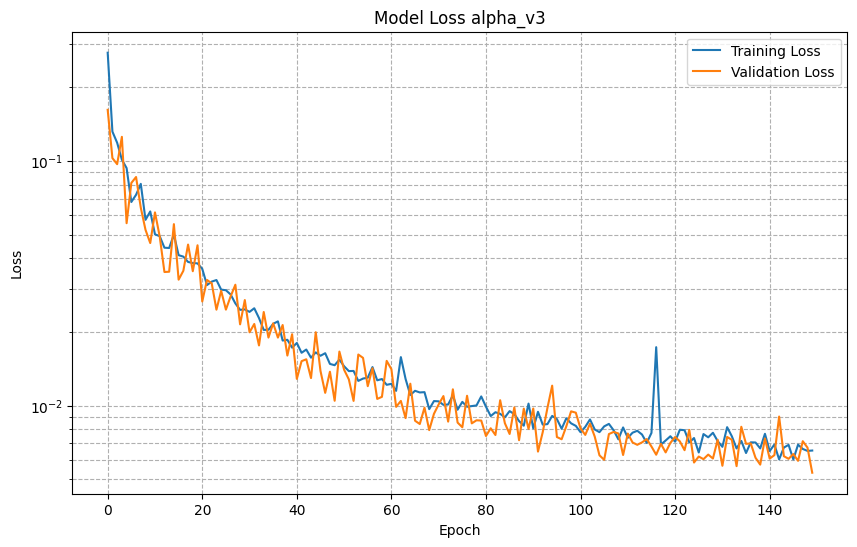


========================= 모델 평가 시작 =========================
40/40 [==============================] - 13s 184ms/step
최종 평가 결과:
  - Global_Mean_Rel_Err(%): 0.6852
  - Global_Max_Rel_Err(%): 16.2063


In [20]:
# 사용자로부터 에포크 수를 입력받도록 설정
try:
    epochs = int(input("훈련할 에포크 수를 입력하세요 (기본값: 150): "))
except (ValueError, TypeError):
    epochs = 150

# 분산 학습 전략 설정
strategy = tf.distribute.MirroredStrategy()
print(f'GPU 개수: {strategy.num_replicas_in_sync}')

# 분산 전략 범위 내에서 모델 생성 및 컴파일
with strategy.scope():
    # 모델 인스턴스 직접 생성
    model = CustomMaxViT3D()
    
    # 옵티마이저 정의
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    
    # 모델 컴파일 (요청하신 대로 loss='mae'로 설정)
    model.compile(
        optimizer=optimizer,
        loss='mae',      # Mean Absolute Error
        #loss = masked_mspe_loss,
        metrics=['mse']  # Mean Squared Error도 함께 모니터링
    )
    print("모델 컴파일 완료.")

# 모델 훈련 시작
print(f"\n{'='*25} 모델 훈련 시작 (Loss: MAE, Epochs: {epochs}) {'='*25}")
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=valid_dataset,
    verbose=1
)

# A. 모델 저장
model_dir = "custom_model_250729"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# .h5 또는 .weights 확장자를 사용할 수 있습니다.
weights_filename = os.path.join(model_dir, "CustomMaxViT3D_alphaV3_Rod_with_mae.h5")

# .save_weights() 메소드를 사용합니다.
model.save_weights(weights_filename)
#model_filename = os.path.join(model_dir, "CustomMaxViT3D_alphaV2_Rod_with_mspe.h5")
#model.save(model_filename)
#print(f"\n모델 저장 완료: {model_filename}")

# B. 학습 과정 시각화 (plot_training_history 함수가 미리 정의되어 있어야 함)
plot_training_history(history, weights_filename)

# C. 테스트 데이터셋으로 예측 및 최종 평가
print(f"\n{'='*25} 모델 평가 시작 {'='*25}")

# C1 Predict: x_test, y_test는 NumPy 배열 형태의 테스트 데이터라고 가정
prediction = model.predict([x_xs_test, x_rod_test], batch_size=GLOBAL_BATCH_SIZE)

# C2 Error Calculate: optimized_error_calculation 함수가 미리 정의되어 있어야 함
eval_metrics = optimized_error_calculation(y_test, prediction)

print("최종 평가 결과:")
for metric_name, value in eval_metrics.items():
    print(f"  - {metric_name}: {value:.4f}")

In [109]:
model_dir

'custom_model_250723'

In [ ]:
# .h5 또는 .weights 확장자를 사용할 수 있습니다.
weights_filename = os.path.join(model_dir, "CustomMaxViT3D_alphaV2_Rod_with_mae.h5")

# .save_weights() 메소드를 사용합니다.
#model.save_weights(weights_filename)

print(f"\n모델 가중치 저장 완료: {weights_filename}")


모델 가중치 저장 완료: custom_model_250729/CustomMaxViT3D_alphaV2_Rod_with_mae.h5


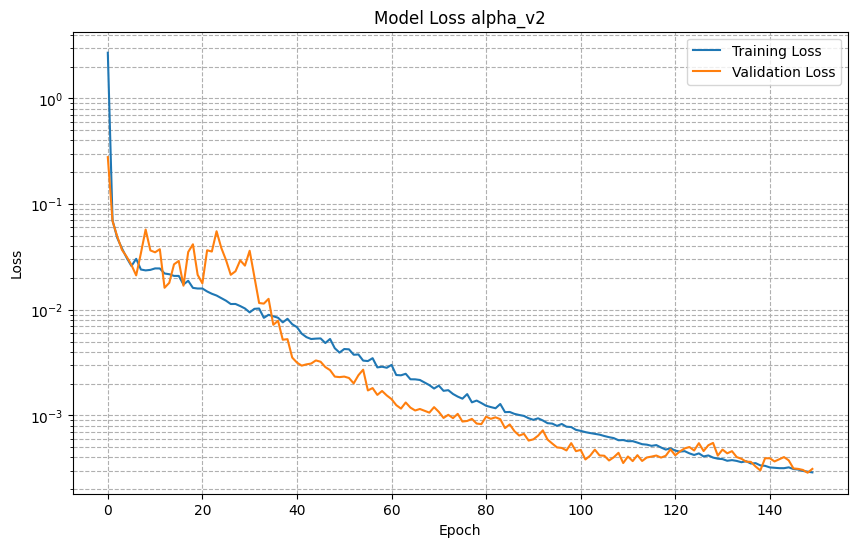


========================= 모델 평가 시작 =========================
40/40 [==============================] - 7s 161ms/step
최종 평가 결과:
  - Global_Mean_Rel_Err(%): 1.3533
  - Global_Max_Rel_Err(%): 16.9357


In [37]:

# B. 학습 과정 시각화 (plot_training_history 함수가 미리 정의되어 있어야 함)
plot_training_history(history, model_filename)

# C. 테스트 데이터셋으로 예측 및 최종 평가
print(f"\n{'='*25} 모델 평가 시작 {'='*25}")

# C1 Predict: x_test, y_test는 NumPy 배열 형태의 테스트 데이터라고 가정
prediction = model.predict([x_xs_test, x_rod_test], batch_size=GLOBAL_BATCH_SIZE)

# C2 Error Calculate: optimized_error_calculation 함수가 미리 정의되어 있어야 함
eval_metrics = optimized_error_calculation(y_test, prediction)

print("최종 평가 결과:")
for metric_name, value in eval_metrics.items():
    print(f"  - {metric_name}: {value:.4f}")

In [21]:
np.save('y_test_MaxViT3D_alphaV3_250730.npy', y_test)
np.save('prediction_MaxViT3D_alphaV3_250730.npy', prediction)

In [110]:
weights_filename

'custom_model_250723/CustomMaxViT3D_alphaV3_Rod_with_mae.h5'

In [17]:
full_path

'custom_model_250723/CustomMaxViT3D_alphaV3_Rod_with_mae.h5'

In [ ]:
import os
import tensorflow as tf

# 1. 모든 경로의 기준이 되는 최상위 디렉토리를 정의합니다.
# 이 경로는 서버 환경에 맞게 정확히 입력해야 합니다.
base_dir = "/home/jskwon/Desktop/projects/ongoing/NTC_SUB3/assy3d_BOC"

# 2. 모델 파일이 들어있는 하위 디렉토리 이름을 정의합니다.
model_subdir = "custom_model_250729"

# 3. 불러올 가중치 파일의 이름을 정의합니다.
weights_filename = "CustomMaxViT3D_alphaV3_Rod_with_mae.h5"

# 4. os.path.join을 사용하여 모든 경로를 합쳐 완전한 절대 경로를 만듭니다.
# 이렇게 하면 실수할 가능성이 크게 줄어듭니다.
weights_full_path = os.path.join(base_dir, model_subdir, weights_filename)

# --- 경로 확인 및 디버깅 ---
print(f"기준 디렉토리: {base_dir}")
print(f"찾으려는 가중치 파일의 전체 경로: {weights_full_path}")

if os.path.exists(weights_full_path):
    print("\n✅ 파일 경로가 올바르며, 파일을 찾았습니다. 로딩을 시작합니다.")
else:
    print(f"\n❌ 오류: '{weights_full_path}' 경로에 파일이 존재하지 않습니다. 경로를 다시 확인해주세요.")
    # 오류가 계속되면 아래 코드의 주석을 풀고 실행하여 실제 파일 목록을 확인해보세요.
    # target_dir_to_check = os.path.join(base_dir, model_subdir)
    # if os.path.isdir(target_dir_to_check):
    #     print(f"'{target_dir_to_check}' 디렉토리의 내용물:", os.listdir(target_dir_to_check))
    # else:
    #     print(f"'{target_dir_to_check}' 디렉토리 자체가 존재하지 않습니다.")


# --- 모델 생성 및 가중치 로드 ---
# 이 부분은 기존 코드와 동일합니다.
model_other = CustomMaxViT3D()

dummy_input_1 = tf.zeros((1, 24, 5, 5, 10), dtype=tf.float32) # dtype을 float32로 맞추는 것이 일반적입니다.
dummy_input_2 = tf.zeros((1, 24, 5, 5), dtype=tf.float32)

_ = model_other([dummy_input_1, dummy_input_2])

# 위에서 만든 완전한 절대 경로(weights_full_path)를 사용하여 가중치를 로드합니다.
try:
    model_other.load_weights(weights_full_path)
    print(f"가중치 로딩 완료: {weights_full_path}")

    # 예측 수행
    # predictions_other = model_other.predict([x_xs_test, x_rod_test], batch_size=GLOBAL_BATCH_SIZE)

except FileNotFoundError:
    print("\n최종적으로 파일 찾기 실패. 위 디버깅 메시지를 참고하여 경로를 수정하세요.")
except Exception as e:
    print(f"\n파일은 찾았지만 다른 오류 발생: {e}")

기준 디렉토리: /home/jskwon/Desktop/projects/ongoing/NTC_SUB3/assy3d_BOC
찾으려는 가중치 파일의 전체 경로: /home/jskwon/Desktop/projects/ongoing/NTC_SUB3/assy3d_BOC/custom_model_250723/CustomMaxViT3D_alphaV3_Rod_with_mae.h5

❌ 오류: '/home/jskwon/Desktop/projects/ongoing/NTC_SUB3/assy3d_BOC/custom_model_250723/CustomMaxViT3D_alphaV3_Rod_with_mae.h5' 경로에 파일이 존재하지 않습니다. 경로를 다시 확인해주세요.

최종적으로 파일 찾기 실패. 위 디버깅 메시지를 참고하여 경로를 수정하세요.


In [23]:
model_dir = "custom_model_250729" 
weights_filename = "CustomMaxViT3D_alphaV3_Rod_with_mae.h5"
full_path = os.path.join(model_dir, weights_filename)

model_other = CustomMaxViT3D()

dummy_input_1 = tf.zeros((1, 24, 5, 5, 10), dtype=tf.float64) # x1 (x_xs_test) 형태
dummy_input_2 = tf.zeros((1, 24, 5, 5), dtype=tf.float64)    # x2 (x_rod_test) 형태

# 모델을 한 번 호출하여 가중치를 생성(빌드)합니다. 
# 출력값은 사용하지 않으므로 _ 변수에 할당합니다.
_ = model_other([dummy_input_1, dummy_input_2])


weights_filename = os.path.join(model_dir, "CustomMaxViT3D_alphaV3_Rod_with_mae.h5")

model_other.load_weights(weights_filename)
print(f"가중치 로딩 완료: {weights_filename}")

# predict 메소드에 입력 데이터들을 리스트로 묶어서 전달합니다.
predictions_other = model_other.predict([x_xs_test, x_rod_test], batch_size=GLOBAL_BATCH_SIZE)
#

가중치 로딩 완료: custom_model_250729/CustomMaxViT3D_alphaV3_Rod_with_mae.h5
40/40 [==============================] - 32s 529ms/step


In [38]:
predictions_other = model_other.predict([x_xs_test, x_rod_test], batch_size=GLOBAL_BATCH_SIZE)
#

40/40 [==============================] - 19s 481ms/step


In [114]:
import time
import numpy as np
import tensorflow as tf

# ... (model_other 생성 및 가중치 로드 완료된 상태) ...

# --- 워밍업용 더미 데이터 준비 ---
# 실제 입력과 shape/dtype이 완벽히 동일해야 합니다.
dummy_input_1 = tf.zeros((1, 24, 5, 5, 10), dtype=tf.float64) 
dummy_input_2 = tf.zeros((1, 24, 5, 5), dtype=tf.float64)

# --- 실제 예측용 데이터 준비 ---
# x_xs_test, x_rod_test 가 준비되어 있다고 가정

print("--- 1. 워밍업 예측 시작 (이 부분이 오래 걸릴 것으로 예상) ---")
start_time_warmup = time.time()
_ = model_other.predict([dummy_input_1, dummy_input_2])
end_time_warmup = time.time()
print(f"==> 워밍업 소요 시간: {end_time_warmup - start_time_warmup:.2f} 초")

print("\n--- 2. 실제 데이터 예측 시작 (이 부분은 빨라야 정상) ---")
start_time_actual = time.time()
predictions_other = model_other.predict([x_xs_test, x_rod_test], batch_size=GLOBAL_BATCH_SIZE)
end_time_actual = time.time()
print(f"==> 실제 예측 소요 시간: {end_time_actual - start_time_actual:.2f} 초")

--- 1. 워밍업 예측 시작 (이 부분이 오래 걸릴 것으로 예상) ---
1/1 [==============================] - 2s 2s/step
==> 워밍업 소요 시간: 2.02 초

--- 2. 실제 데이터 예측 시작 (이 부분은 빨라야 정상) ---
40/40 [==============================] - 19s 485ms/step
==> 실제 예측 소요 시간: 19.60 초


#### 오차함수

In [ ]:
prediction.shape

(3754, 24, 5, 5)

In [24]:
# prediction = model.predict([x_xs_test, x_rod_test], batch_size=GLOBAL_BATCH_SIZE)
pred_symmetric = apply_symmetry(predictions_other)

calculate_global_voxel_errors(y_test, pred_symmetric)
calculate_peak_value_errors(y_test, pred_symmetric)
calculate_peak_accuracy_symmetric(y_test, pred_symmetric)

NameError: name 'apply_symmetry' is not defined

In [110]:
def calculate_global_voxel_errors(y_true, y_pred, voxel_type = "assy", epsilon=1e-08):
    # voxel_type = "assy" / "pin"
    if voxel_type == "assy":
        # --- 마스크 생성 ---
        mask_radial = np.ones((5, 5), dtype=bool)
        mask_radial[3, 4] = False
        mask_radial[4, 3] = False
        mask_radial[4, 4] = False
        # 처음부터 boolean으로 만들면 .astype(bool)이 필요 없습니다.

        # (24, 5, 5) 형태로 복셀 마스크 생성
        mask_voxel = np.tile(mask_radial, (24, 1, 1))

        # --- MAPE 계산 ---

        # 1. 마스크를 사용해 관심 영역의 데이터만 추출
        y_true_masked = y_true[:, mask_voxel] # y_test/pred_squeezed의 각 샘플에 동일한 마스크를 적용
        pred_masked = y_pred[:, mask_voxel]

        # 2. 0으로 나누기 방지를 위한 epsilon 설정
        epsilon = epsilon

        # 3. 마스킹된 데이터에 대해 APE(절대 백분율 오차) 계산
        percent_errors = np.abs((y_true_masked - pred_masked) / (y_true_masked + epsilon)) * 100

        # 4. 모든 APE의 평균을 내어 최종 MAPE(평균 절대 백분율 오차) 계산
        global_mape = np.mean(percent_errors)
        global_maxape = np.max(percent_errors)

        print(f"관심 영역(ROI) 내 전역 평균 절대 백분율 오차 (Global MAPE): {global_mape:.3f}%")
        print(f"관심 영역(ROI) 내 전역 최대 절대 백분율 오차 (Global MaxAPE): {global_maxape:.3f}%")
        
        return global_mape, global_maxape
    
        


In [111]:
def calculate_peak_value_errors(y_true, y_pred, voxel_type = "assy", epsilon=1e-08):

    # axis=(1, 2, 3)을 지정하여 해당 축들을 기준으로 최댓값을 계산
    # (3754, 24, 5, 5) -> (3754,)의 배열이 생성
    peak_values_pred_vectorized = np.max(y_pred, axis=(1, 2, 3))
    peak_values_true_vectorized = np.max(y_test, axis=(1, 2, 3))

    # print(f"예측값 Peak 배열 Shape: {peak_values_pred_vectorized.shape}")
    # print(f"실제값 Peak 배열 Shape: {peak_values_true_vectorized.shape}")

    percent_errors_peak_values = abs((peak_values_true_vectorized-peak_values_pred_vectorized)/peak_values_true_vectorized+epsilon)*100
    peak_value_mape = np.mean(percent_errors_peak_values)
    peak_value_maxape = np.max(percent_errors_peak_values)

    print(f"관심 영역(ROI) 내 Peak 예측의 전역 평균 절대 백분율 오차 (Global MAPE): {peak_value_mape:.3f}%")
    print(f"관심 영역(ROI) 내 Peak 예측의 전역 최대 절대 백분율 오차 (Global MaxAPE): {peak_value_maxape:.3f}%")

    return peak_value_mape, peak_value_maxape

In [112]:
def calculate_peak_accuracy_symmetric(y_true, y_pred):
    """
    대칭성을 고려하여 각 샘플의 Peak 위치 예측 정확도를 계산하는 함수.
    예측 피크 위치가 실제 피크 위치 또는 그 대칭 위치와 일치하면 정답으로 처리합니다.

    Args:
        y_true (np.ndarray): 실제값 배열. (샘플 수, 24, 5, 5) 형태.
        y_pred (np.ndarray): 예측값 배열. (샘플 수, 24, 5, 5) 형태.

    Returns:
        float: Peak 위치 예측 정확도 (%).
    """
    # --- 1. Reshape & Flatten ---
    num_samples = y_pred.shape[0]
    voxel_size = np.prod(y_pred.shape[1:])
    pred_reshaped = y_pred.reshape(num_samples, voxel_size)
    y_true_reshaped = y_true.reshape(num_samples, voxel_size)

    # --- 2. Find 1D indices of max values ---
    flat_indices_pred = np.argmax(pred_reshaped, axis=1)
    flat_indices_true = np.argmax(y_true_reshaped, axis=1)

    # --- 3. Unravel 1D indices back to 3D indices ---
    voxel_shape = y_pred.shape[1:]
    voxel_indices_pred = np.unravel_index(flat_indices_pred, voxel_shape)
    voxel_indices_true = np.unravel_index(flat_indices_true, voxel_shape)

    # --- 4. Stack indices to (N, 3) arrays ---
    peak_indices_pred = np.stack(voxel_indices_pred, axis=1) # (샘플수, 3) [z, y, x]
    peak_indices_true = np.stack(voxel_indices_true, axis=1) # (샘플수, 3) [z, y, x]

    # --- 5. 대칭성을 고려하여 정확도 계산 (수정된 부분) ---

    # 5a. 정답 인덱스의 z, y, x를 분리
    true_z = peak_indices_true[:, 0]
    true_y = peak_indices_true[:, 1]
    true_x = peak_indices_true[:, 2]

    # 5b. 대칭 관계에 있는 정답 인덱스 배열 생성: (z, x, y)
    peak_indices_true_symmetric = np.stack([true_z, true_x, true_y], axis=1)

    # 5c. 두 가지 경우에 대해 일치 여부 확인
    # 경우 1: 예측 인덱스가 원본 정답 인덱스와 일치하는가?
    # (pred_z == true_z) AND (pred_y == true_y) AND (pred_x == true_x)
    matches_direct = np.all(peak_indices_pred == peak_indices_true, axis=1)
    
    # 경우 2: 예측 인덱스가 대칭 정답 인덱스와 일치하는가?
    # (pred_z == true_z) AND (pred_y == true_x) AND (pred_x == true_y)
    matches_symmetric = np.all(peak_indices_pred == peak_indices_true_symmetric, axis=1)

    # 5d. 두 경우 중 하나라도 만족하면 최종 정답으로 처리 (logical OR)
    final_matches = np.logical_or(matches_direct, matches_symmetric)
    
    accuracy = np.mean(final_matches) * 100
    
    return accuracy

In [113]:
def apply_symmetry(tensor):
  """
  텐서의 마지막 두 축을 기준으로 대각 대칭 행렬로 변환합니다.
  (y, x)와 (x, y) 요소의 평균값을 계산하여 두 위치에 모두 적용합니다.

  Args:
    tensor: (..., H, W) 형태의 NumPy 배열.
            여기서는 (batch_size, 24, 5, 5) 형태의 텐서입니다.

  Returns:
    마지막 두 축이 대각 대칭으로 변환된 새로운 텐서.
  """
  # 마지막 두 축(y, x)을 전치(transpose)합니다.
  # 예를 들어, (0, 1, 2, 3) 축을 (0, 1, 3, 2) 순서로 바꿉니다.
  transposed_tensor = np.transpose(tensor, axes=(0, 1, 3, 2))

  # 원본 텐서와 전치된 텐서를 더한 후 2로 나누어 평균을 구합니다.
  symmetric_tensor = (tensor + transposed_tensor) / 2

  return symmetric_tensor

### 오차함수 (250731)

In [31]:

# pred = model_temp.predict([x1_test,x2_test])
# pred_squeezed = np.squeeze(pred, axis=-1)
pred_symmetric = apply_symmetry(predictions_other)

calculate_global_voxel_errors(y_test, pred_symmetric)
calculate_peak_value_errors(y_test, pred_symmetric)
calculate_peak_accuracy_symmetric(y_test, pred_symmetric)
calculate_peak_accuracy_z_tolerant(y_test, pred_symmetric)
calculate_peak_accuracy_xy_plane(y_test, pred_symmetric)

관심 영역(ROI) 내 전역 평균 절대 백분율 오차 (Global MAPE): 0.694%
관심 영역(ROI) 내 전역 최대 절대 백분율 오차 (Global MaxAPE): 20.196%
관심 영역(ROI) 내 Peak 예측의 전역 평균 절대 백분율 오차 (Global MAPE): 0.461%
관심 영역(ROI) 내 Peak 예측의 전역 최대 절대 백분율 오차 (Global MaxAPE): 3.913%
Peak 위치 (z,y,x) 예측 정확도: 93.37%
Peak 위치 (z+-1,y,x) 예측 정확도: 98.08%
Peak 위치 (:,y,x) 예측 정확도: 98.08%


98.08204581779435

In [25]:
def calculate_global_voxel_errors(y_true, y_pred, voxel_type = "assy", epsilon=1e-08):
    # voxel_type = "assy" / "pin"
    if voxel_type == "assy":
        # --- 마스크 생성 ---
        mask_radial = np.ones((5, 5), dtype=bool)
        mask_radial[3, 4] = False
        mask_radial[4, 3] = False
        mask_radial[4, 4] = False
        # 처음부터 boolean으로 만들면 .astype(bool)이 필요 없습니다.

        # (24, 5, 5) 형태로 복셀 마스크 생성
        mask_voxel = np.tile(mask_radial, (24, 1, 1))

        # --- MAPE 계산 ---

        # 1. 마스크를 사용해 관심 영역의 데이터만 추출
        y_test_masked = y_true[:, mask_voxel] # y_test/pred_squeezed의 각 샘플에 동일한 마스크를 적용
        pred_masked = y_pred[:, mask_voxel]

        # 2. 0으로 나누기 방지를 위한 epsilon 설정
        epsilon = epsilon

        # 3. 마스킹된 데이터에 대해 APE(절대 백분율 오차) 계산
        percent_errors = np.abs((y_test_masked - pred_masked) / (y_test_masked + epsilon)) * 100

        # 4. 모든 APE의 평균을 내어 최종 MAPE(평균 절대 백분율 오차) 계산
        global_mape = np.mean(percent_errors)
        global_maxape = np.max(percent_errors)

        print(f"관심 영역(ROI) 내 전역 평균 절대 백분율 오차 (Global MAPE): {global_mape:.3f}%")
        print(f"관심 영역(ROI) 내 전역 최대 절대 백분율 오차 (Global MaxAPE): {global_maxape:.3f}%")
        
        return global_mape, global_maxape
    
        


In [26]:
def calculate_peak_value_errors(y_true, y_pred, voxel_type = "assy", epsilon=1e-08):

    # axis=(1, 2, 3)을 지정하여 해당 축들을 기준으로 최댓값을 계산
    # (3754, 24, 5, 5) -> (3754,)의 배열이 생성
    peak_values_pred_vectorized = np.max(y_pred, axis=(1, 2, 3))
    peak_values_true_vectorized = np.max(y_true, axis=(1, 2, 3))

    # print(f"예측값 Peak 배열 Shape: {peak_values_pred_vectorized.shape}")
    # print(f"실제값 Peak 배열 Shape: {peak_values_true_vectorized.shape}")

    percent_errors_peak_values = abs((peak_values_true_vectorized-peak_values_pred_vectorized)/peak_values_true_vectorized+epsilon)*100
    peak_value_mape = np.mean(percent_errors_peak_values)
    peak_value_maxape = np.max(percent_errors_peak_values)

    print(f"관심 영역(ROI) 내 Peak 예측의 전역 평균 절대 백분율 오차 (Global MAPE): {peak_value_mape:.3f}%")
    print(f"관심 영역(ROI) 내 Peak 예측의 전역 최대 절대 백분율 오차 (Global MaxAPE): {peak_value_maxape:.3f}%")

    return peak_value_mape, peak_value_maxape

In [27]:
def calculate_peak_accuracy_z_tolerant(y_true, y_pred):
    """
    (신규 지표 1) Z축 근접성을 허용하여 Peak 위치 예측 정확도를 계산합니다.
    기존 대칭 정확도 조건에 더해, (x,y)가 일치하고 z가 ±1 차이 나도 정답으로 인정합니다.

    Args:
        y_true (np.ndarray): 실제값 배열.
        y_pred (np.ndarray): 예측값 배열.

    Returns:
        float: Z축 근접성을 허용한 Peak 위치 예측 정확도 (%).
    """
    # --- 1. Reshape & Find 1D/3D indices (공통 로직) ---
    num_samples = y_pred.shape[0]
    voxel_shape = y_pred.shape[1:]
    
    pred_reshaped = y_pred.reshape(num_samples, -1)
    y_true_reshaped = y_true.reshape(num_samples, -1)

    flat_indices_pred = np.argmax(pred_reshaped, axis=1)
    flat_indices_true = np.argmax(y_true_reshaped, axis=1)

    peak_indices_pred = np.stack(np.unravel_index(flat_indices_pred, voxel_shape), axis=1)
    peak_indices_true = np.stack(np.unravel_index(flat_indices_true, voxel_shape), axis=1)

    # --- 2. 기존 대칭 정확도 계산 ---
    pred_z, pred_y, pred_x = peak_indices_pred[:, 0], peak_indices_pred[:, 1], peak_indices_pred[:, 2]
    true_z, true_y, true_x = peak_indices_true[:, 0], peak_indices_true[:, 1], peak_indices_true[:, 2]

    peak_indices_true_symmetric = np.stack([true_z, true_x, true_y], axis=1)
    matches_direct = np.all(peak_indices_pred == peak_indices_true, axis=1)
    matches_symmetric = np.all(peak_indices_pred == peak_indices_true_symmetric, axis=1)
    base_matches = np.logical_or(matches_direct, matches_symmetric)

    # --- 3. Z축 근접 허용 조건 추가 ---
    # 조건 A: (y,x) 좌표가 직접 또는 대칭으로 일치하는가?
    xy_match_direct = (pred_y == true_y) & (pred_x == true_x)
    xy_match_symmetric = (pred_y == true_x) & (pred_x == true_y)
    xy_match_any = np.logical_or(xy_match_direct, xy_match_symmetric)
    
    # 조건 B: z 좌표가 위 또는 아래로 인접하는가?
    z_is_adjacent = np.logical_or(pred_z == true_z - 1, pred_z == true_z + 1)

    # Z축 근접 정답: 조건 A와 조건 B를 모두 만족
    matches_z_tolerant = np.logical_and(xy_match_any, z_is_adjacent)

    # --- 4. 최종 정확도 계산 ---
    # 기본 정답 또는 Z축 근접 정답 중 하나라도 만족하면 최종 정답
    final_matches = np.logical_or(base_matches, matches_z_tolerant)
    
    accuracy = np.mean(final_matches) * 100
    
    print(f"Peak 위치 (z+-1,y,x) 예측 정확도: {accuracy:.2f}%")
    
    return accuracy

In [28]:
def calculate_peak_accuracy_xy_plane(y_true, y_pred):
    """
    (신규 지표 2) Z축을 무시하고 XY 평면의 대칭성만으로 Peak 위치 정확도를 계산합니다.
    예측 피크의 (y,x) 좌표가 실제 피크의 (y,x) 또는 (x,y)와 일치하면 정답으로 처리합니다.

    Args:
        y_true (np.ndarray): 실제값 배열.
        y_pred (np.ndarray): 예측값 배열.

    Returns:
        float: XY 평면 투영 Peak 위치 예측 정확도 (%).
    """
    # --- 1. Reshape & Find 1D/3D indices (공통 로직) ---
    num_samples = y_pred.shape[0]
    voxel_shape = y_pred.shape[1:]
    
    pred_reshaped = y_pred.reshape(num_samples, -1)
    y_true_reshaped = y_true.reshape(num_samples, -1)

    flat_indices_pred = np.argmax(pred_reshaped, axis=1)
    flat_indices_true = np.argmax(y_true_reshaped, axis=1)

    peak_indices_pred = np.stack(np.unravel_index(flat_indices_pred, voxel_shape), axis=1)
    peak_indices_true = np.stack(np.unravel_index(flat_indices_true, voxel_shape), axis=1)

    # --- 2. XY 평면 좌표만 추출 ---
    pred_y, pred_x = peak_indices_pred[:, 1], peak_indices_pred[:, 2]
    true_y, true_x = peak_indices_true[:, 1], peak_indices_true[:, 2]

    # --- 3. XY 평면에서의 대칭 정확도 계산 ---
    # 경우 1: (y,x) 좌표가 직접 일치
    matches_direct_xy = (pred_y == true_y) & (pred_x == true_x)
    
    # 경우 2: (y,x) 좌표가 대각 대칭으로 일치 (pred(y,x) == true(x,y))
    matches_symmetric_xy = (pred_y == true_x) & (pred_x == true_y)

    # 두 경우 중 하나라도 만족하면 최종 정답
    final_matches = np.logical_or(matches_direct_xy, matches_symmetric_xy)
    
    accuracy = np.mean(final_matches) * 100
    
    print(f"Peak 위치 (:,y,x) 예측 정확도: {accuracy:.2f}%")
    
    return accuracy

In [29]:
def calculate_peak_accuracy_symmetric(y_true, y_pred):
    """
    대칭성을 고려하여 각 샘플의 Peak 위치 예측 정확도를 계산하는 함수.
    예측 피크 위치가 실제 피크 위치 또는 그 대칭 위치와 일치하면 정답으로 처리합니다.

    Args:
        y_true (np.ndarray): 실제값 배열. (샘플 수, 24, 5, 5) 형태.
        y_pred (np.ndarray): 예측값 배열. (샘플 수, 24, 5, 5) 형태.

    Returns:
        float: Peak 위치 예측 정확도 (%).
    """
    # --- 1. Reshape & Flatten ---
    num_samples = y_pred.shape[0]
    voxel_size = np.prod(y_pred.shape[1:])
    pred_reshaped = y_pred.reshape(num_samples, voxel_size)
    y_true_reshaped = y_true.reshape(num_samples, voxel_size)

    # --- 2. Find 1D indices of max values ---
    flat_indices_pred = np.argmax(pred_reshaped, axis=1)
    flat_indices_true = np.argmax(y_true_reshaped, axis=1)

    # --- 3. Unravel 1D indices back to 3D indices ---
    voxel_shape = y_pred.shape[1:]
    voxel_indices_pred = np.unravel_index(flat_indices_pred, voxel_shape)
    voxel_indices_true = np.unravel_index(flat_indices_true, voxel_shape)

    # --- 4. Stack indices to (N, 3) arrays ---
    peak_indices_pred = np.stack(voxel_indices_pred, axis=1) # (샘플수, 3) [z, y, x]
    peak_indices_true = np.stack(voxel_indices_true, axis=1) # (샘플수, 3) [z, y, x]

    # --- 5. 대칭성을 고려하여 정확도 계산 (수정된 부분) ---

    # 5a. 정답 인덱스의 z, y, x를 분리
    true_z = peak_indices_true[:, 0]
    true_y = peak_indices_true[:, 1]
    true_x = peak_indices_true[:, 2]

    # 5b. 대칭 관계에 있는 정답 인덱스 배열 생성: (z, x, y)
    peak_indices_true_symmetric = np.stack([true_z, true_x, true_y], axis=1)

    # 5c. 두 가지 경우에 대해 일치 여부 확인
    # 경우 1: 예측 인덱스가 원본 정답 인덱스와 일치하는가?
    # (pred_z == true_z) AND (pred_y == true_y) AND (pred_x == true_x)
    matches_direct = np.all(peak_indices_pred == peak_indices_true, axis=1)
    
    # 경우 2: 예측 인덱스가 대칭 정답 인덱스와 일치하는가?
    # (pred_z == true_z) AND (pred_y == true_x) AND (pred_x == true_y)
    matches_symmetric = np.all(peak_indices_pred == peak_indices_true_symmetric, axis=1)

    # 5d. 두 경우 중 하나라도 만족하면 최종 정답으로 처리 (logical OR)
    final_matches = np.logical_or(matches_direct, matches_symmetric)
    
    accuracy = np.mean(final_matches) * 100
    print(f"Peak 위치 (z,y,x) 예측 정확도: {accuracy:.2f}%")
    
    return accuracy

In [30]:
def apply_symmetry(tensor):
  """
  텐서의 마지막 두 축을 기준으로 대각 대칭 행렬로 변환합니다.
  (y, x)와 (x, y) 요소의 평균값을 계산하여 두 위치에 모두 적용합니다.

  Args:
    tensor: (..., H, W) 형태의 NumPy 배열.
            여기서는 (batch_size, 24, 5, 5) 형태의 텐서입니다.

  Returns:
    마지막 두 축이 대각 대칭으로 변환된 새로운 텐서.
  """
  # 마지막 두 축(y, x)을 전치(transpose)합니다.
  # 예를 들어, (0, 1, 2, 3) 축을 (0, 1, 3, 2) 순서로 바꿉니다.
  transposed_tensor = np.transpose(tensor, axes=(0, 1, 3, 2))

  # 원본 텐서와 전치된 텐서를 더한 후 2로 나누어 평균을 구합니다.
  symmetric_tensor = (tensor + transposed_tensor) / 2

  return symmetric_tensor